# Examen Python data developer
# Deel 1
## Introductie
Voor dit examen is het belangrijk dat je volgende zaken zeker doet:
 - Maak een Vitual Environment aan & exporteer een `.yml` (of soortgelijke) file aan die je toevoegt aan je codebase.
 - Maak een github pagina aan met een bijhorende `.gitignore` en `readme.md`. Voeg een link naar de github repo toe aan je readme file.
 - Zorg dat je op het einde de tijd neemt om je code op te schonen zodat deze begrijpelijk is voor derden.
 - Wanneer je klaar bent, maak een `.zip` bestand van je volledige codebase aan en laad deze op in de leeromgeving.

In deze opgave bekijken we een gesimuleerde dataset over de geboortes in België van 2019. De data is te vinden in `.csv` bestanden die gelabeld zijn met de echte geboortedag van de personen in het bestand. Laat ons bijvoorbeeld even kijken naar de eerste 5 lijnen van het bestand `2019-1-1.csv`:

<table align="center">
  <tr>
    <th>gemeente</th>
    <th>naam</th>
    <th>geslacht</th>
    <th>verwachte datum</th>
  </tr>
  <tr>
    <td>Hooglede</td>
    <td>Elias</td>
    <td>Mannelijk</td>
    <td>01/14/2019</td>
  </tr>
  <tr>
    <td>Sint-Niklaas (Sint-Niklaas)</td>
    <td>Pauline</td>
    <td>Vrouwelijk</td>
    <td>01/05/2019</td>
  </tr>
  <tr>
    <td>Wijnegem</td>
    <td>Anita</td>
    <td>Vrouwelijk</td>
    <td>01/05/2019</td>
  </tr>
  <tr>
    <td>Grâce-Hollogne</td>
    <td>Jean-Paul</td>
    <td>Mannelijk</td>
    <td>01/13/2019</td>
  </tr>
  <tr>
    <td>Boussu</td>
    <td>François</td>
    <td>Mannelijk</td>
    <td>01/26/2019</td>
  </tr>
</table>


Hier hebben we de kolommen:
 - **gemeente**: De gemeente waar de persoon geboren is.
 - **naam**: De voornaam van de persoon.
 - **geslacht**: Het geslacht van de persoon (Mannelijk of Vrouwelijk).
 - **verwachte datum**: De verwachte geboortedatum van de persoon.

Dus hier hebben we dan bijvoorbeeld op de eerste lijn de mannelijke persoon Elias die geboren is in Hooglede waarvan men verwachtte dat hij zou geboren worden op `01/14/2019` (Amerikaans formaat) maar in feite geboren is op 1 januari 2019.

Doorheen deze opgave gaan we de data van dichterbij inspecteren! Je kan deze opgaves alternatief lezen in de bijgeleverde notebook `examen.ipynb` waar ook de (meeste) afbeeldingen & resultaten zichtbaar zijn.

## Visualisaties

Wanneer er je gevraagd wordt een visualisatie te maken krijg je minimale instructies. Tijdens de lessenreeks zagen we een heel aantal best practices, pas deze toe ook al wordt dit niet telkens expliciet aangegeven in de instructies.


## Puntenverdeling
**Het totale examen staat op X punten.**

Mondelinge toelichting voor alles
 - 50%: Je snapt wat je gedaan hebt.
 - 50%: Je kan bijvragen beantwoorden

In [1]:
%load_ext autoreload
%autoreload 2

## Utilities

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date
from pathlib import Path
import matplotlib.ticker as mticker

from syntradsexamen.config import DATA_DIR, YEAR, COL_GEMEENTE, COL_NAAM, COL_GESLACHT, COL_VERWACHTE_DATUM, COL_GEBOORTEDATUM, COL_DAG_VAN_HET_JAAR

from syntradsexamen.styling import MEAN_COLOR, MEDIAN_COLOR, P25_COLOR, P75_COLOR, GRAY, TAN, SAGE, GOLDENROD, SLATE, ROSY, OLIVE, BROWN, CADET, PALETTE, standard_style

In [3]:
standard_style()

## Stap 1: data inlezen (1 pnt)

Bouw één DataFrame `df_births` met alle geboortes uit de map `data/geboortes`.

**Output**
- `df_births` bevat alle rijen uit alle CSV-bestanden.
- `df_births` bevat een kolom `date` als echte datetime (`YYYY-MM-DD`), afgeleid uit de bestandsnaam.
- `df_births` bevat een kolom `dag_van_jaar` met waarden van 1 tot 365.
- De observatie-grain is identiek aan de bron: **1 rij = 1 geboorte**.

**Te tonen checks**
- Aantal rijen in `df_births`
- Minimum- en maximumdatum
- Minimum en maximum van `day_of_year`
- Geen onbestaande datums (bv. dag 0, dag 32, 29/2 in niet-schrikkeljaren, geboortejaar 2027,...)

---

In [ ]:
loaded_files = []
skipped_files = []
frames = []

for csv_path in sorted(DATA_DIR.glob("*.csv")):
    stem = csv_path.stem    # stem is het naamgedeelte van de filename, bv "2019-1-1"
    parts = stem.split("-") # split het stemgedeelte van de filenaam op - 

    # Er moeten drie delen in parts zitten: YYYY-M-D
    if len(parts) != 3:
        skipped_files.append(csv_path.name)
        continue

    # Maak een datum op basis van parts
    try:
        y, m, d = int(parts[0]), int(parts[1]), int(parts[2])
        geboortedatum = date(y, m, d)
    except (ValueError, IndexError):
        skipped_files.append(csv_path.name) # als je geen datum kan maken: filenaam toevoegen aan list skipped_files
        continue

    # Enkel geboortejaar 2019 behouden 
    if y != YEAR:
        skipped_files.append(csv_path.name)
        continue

    # Read csv 
    df_tmp = pd.read_csv(csv_path, encoding="utf-8-sig") # maak een df van elke file 

    # Hernoem "verwachte datum" → "verwachte_datum" in die kleine df 
    df_tmp = df_tmp.rename(columns={"verwachte datum": COL_VERWACHTE_DATUM})

    # Voeg kolommen toe: geboortedatum uit de filenaam en dag van het jaar (nr van 1-365) in die kleine df
    df_tmp[COL_GEBOORTEDATUM] = pd.Timestamp(geboortedatum)
    df_tmp[COL_DAG_VAN_HET_JAAR] = geboortedatum.timetuple().tm_yday

    frames.append(df_tmp) # voeg de kleine df toe aan de list "frames"
    loaded_files.append(csv_path.name) # als je de kleine df in de frames steekt, voeg dan de filenaam toe aan list loaded files

df_births = pd.concat(frames, ignore_index=True)

# Parse verwachte_datum to datetime
df_births[COL_VERWACHTE_DATUM] = pd.to_datetime(
    df_births[COL_VERWACHTE_DATUM], format="mixed", dayfirst=False
)

print(f"Loaded: {len(loaded_files)} files")
print(f"Skipped: {len(skipped_files)} files: {skipped_files}")
print(f"Total rows: {len(df_births):,}")
df_births.head()

Loaded: 365 files
Skipped: 1 files: ['2019-2-29.csv']
Total rows: 116,850


,gemeente,naam,geslacht,verwachte_datum,geboortedatum,dag_van_jaar
0,Hooglede,Elias,Mannelijk,2019-01-14,2019-01-01,1
1,Sint-Niklaas (Sint-Niklaas),Pauline,Vrouwelijk,2019-01-05,2019-01-01,1
2,Wijnegem,Anita,Vrouwelijk,2019-01-05,2019-01-01,1
3,Grâce-Hollogne,Jean-Paul,Mannelijk,2019-01-13,2019-01-01,1
4,Boussu,François,Mannelijk,2019-01-26,2019-01-01,1


In [6]:
# ── Checks ──────────────────────────────────────────────────────────────
print(f"Aantal rijen:           {len(df_births):,}")
print(f"Min geboortedatum:      {df_births[COL_GEBOORTEDATUM].min().date()}")
print(f"Max geboortedatum:      {df_births[COL_GEBOORTEDATUM].max().date()}")
print(f"Min dag_van_het_jaar:   {df_births[COL_DAG_VAN_HET_JAAR].min()}")
print(f"Max dag_van_het_jaar:   {df_births[COL_DAG_VAN_HET_JAAR].max()}")
print(f"Unieke geboortedatums:  {df_births[COL_GEBOORTEDATUM].nunique()}")
print(f"Dtype geboortedatum:    {df_births[COL_GEBOORTEDATUM].dtype}")
print(f"Dtype verwachte_datum:  {df_births[COL_VERWACHTE_DATUM].dtype}")
print(f"Nulls verwachte_datum:  {df_births[COL_VERWACHTE_DATUM].isna().sum()}")

# Assertions
assert pd.api.types.is_datetime64_any_dtype(df_births[COL_GEBOORTEDATUM]), \
    "geboortedatum is geen datetime."
assert pd.api.types.is_datetime64_any_dtype(df_births[COL_VERWACHTE_DATUM]), \
    "verwachte_datum is geen datetime."
assert df_births[COL_GEBOORTEDATUM].dt.year.eq(YEAR).all(), \
    "Niet alle geboortedatums zijn in 2019."
assert df_births[COL_DAG_VAN_HET_JAAR].between(1, 365).all(), \
    "dag_van_het_jaar buiten bereik."
assert df_births[COL_GEBOORTEDATUM].notna().all(), \
    "Ontbrekende geboortedatums."
assert df_births[COL_VERWACHTE_DATUM].notna().all(), \
    "Ontbrekende verwachte_datums."


Aantal rijen:           116,850
Min geboortedatum:      2019-01-01
Max geboortedatum:      2019-12-31
Min dag_van_het_jaar:   1
Max dag_van_het_jaar:   365
Unieke geboortedatums:  365
Dtype geboortedatum:    datetime64[s]
Dtype verwachte_datum:  datetime64[ns]
Nulls verwachte_datum:  0


## Stap 2: EDA

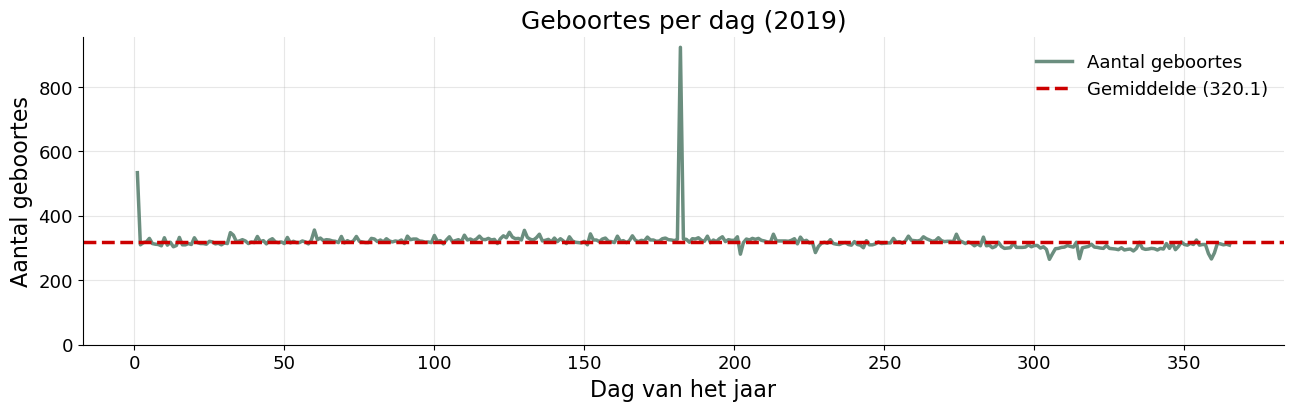

In [7]:
df = df_births.copy()
daily = (
    df
    .groupby("dag_van_jaar", as_index=False)
    .size()
    .rename(columns={"size": "geboortes"})
    .sort_values("dag_van_jaar")     
)

gemiddelde_geboortes = daily["geboortes"].mean()

fig, ax = plt.subplots(figsize=(15.5, 4))
ax.plot(daily["dag_van_jaar"], daily["geboortes"], label = "Aantal geboortes")

ax.set_title("Geboortes per dag (2019)")
ax.set_xlabel("Dag van het jaar")
ax.set_ylabel("Aantal geboortes")
ax.set_ylim(bottom=0)
ax.yaxis.set_major_locator(plt.MultipleLocator(200))
ax.grid(True, alpha=0.3)

# Horizontal dashed mean line
ax.axhline(
    y=gemiddelde_geboortes,
    color=MEAN_COLOR,
    linestyle="--",
    label=f"Gemiddelde ({gemiddelde_geboortes:.1f})"
)

ax.legend()
plt.show()

### Vraag 2: Outliers vinden & behandelen

#### Vraag 2.1 Zoek alle outliers in de dataset. (1 pnt)

Kies een regel om een datapunt als 'outlier' te classifieren, pas deze toe en verdedig je keuze.

In [ ]:
# Outlier detectie met IQR
# De IQR-methode bekijkt de verdeling van alle dagelijkse geboortecijfers.
# Q1 = 25e percentiel, Q3 = 75e percentiel, IQR = Q3 − Q1.
# Een dag is een outlier als het aantal geboortes buiten [Q1 − 1.5·IQR, Q3 + 1.5·IQR] valt (standaard stat)

Q1 = daily["geboortes"].quantile(0.25)
Q3 = daily["geboortes"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("── IQR-methode ──")
print(f"Q1:            {Q1:.1f}")
print(f"Q3:            {Q3:.1f}")
print(f"IQR:           {IQR:.1f}")
print(f"Ondergrens:    {lower_bound:.1f}")
print(f"Bovengrens:    {upper_bound:.1f}")

outliers_iqr = daily.loc[
    (daily["geboortes"] < lower_bound) | (daily["geboortes"] > upper_bound)
].copy()

# Voeg de datum toe voor leesbaarheid
dag_to_date = df_births[[COL_DAG_VAN_HET_JAAR, COL_GEBOORTEDATUM]].drop_duplicates()
outliers_iqr = outliers_iqr.merge(dag_to_date, on=COL_DAG_VAN_HET_JAAR)

# Sorteer op afstand tot mediaan (meest extreme bovenaan)
mediaan = daily["geboortes"].median()
outliers_iqr["afstand"] = (outliers_iqr["geboortes"] - mediaan).abs()
outliers_iqr = outliers_iqr.sort_values("afstand", ascending=False)

print(f"\nAantal outliers: {len(outliers_iqr)}")
for _, row in outliers_iqr.iterrows():
    print(f"  {row[COL_GEBOORTEDATUM].date()} (dag {row[COL_DAG_VAN_HET_JAAR]}): "
          f"{row['geboortes']} geboortes  (afstand tot mediaan: {row['afstand']:.0f})")

# ── Conclusie ────────────────────────────────────────────────────────────
# De IQR-methode vindt meerdere outliers, maar 2 dagen springen er
# duidelijk bovenuit: zij hebben veruit de grootste afstand tot de mediaan.
# Deze 2 onderzoeken we verder in Q2.2.

top2 = sorted(outliers_iqr.head(2)[COL_GEBOORTEDATUM].tolist())

print(f"\nDe 2 meest extreme outliers:")
print(top2)

── IQR-methode ──
Q1:            311.0
Q3:            325.0
IQR:           14.0
Ondergrens:    290.0
Bovengrens:    346.0

Aantal outliers: 14
  2019-07-01 (dag 182): 923 geboortes  (afstand tot mediaan: 603)
  2019-01-01 (dag 1): 534 geboortes  (afstand tot mediaan: 214)
  2019-11-01 (dag 305): 265 geboortes  (afstand tot mediaan: 55)
  2019-12-25 (dag 359): 266 geboortes  (afstand tot mediaan: 54)
  2019-11-11 (dag 315): 267 geboortes  (afstand tot mediaan: 53)
  2019-07-21 (dag 202): 281 geboortes  (afstand tot mediaan: 39)
  2019-11-02 (dag 306): 282 geboortes  (afstand tot mediaan: 38)
  2019-12-24 (dag 358): 283 geboortes  (afstand tot mediaan: 37)
  2019-03-01 (dag 60): 356 geboortes  (afstand tot mediaan: 36)
  2019-05-10 (dag 130): 355 geboortes  (afstand tot mediaan: 35)
  2019-12-26 (dag 360): 285 geboortes  (afstand tot mediaan: 35)
  2019-08-15 (dag 227): 286 geboortes  (afstand tot mediaan: 34)
  2019-05-05 (dag 125): 349 geboortes  (afstand tot mediaan: 29)
  2019-02-01 

#### Vraag 2.2 Outlier remediation (1 pnt)
Je stelt vast dat twee dagen eruit springen als outliers. Corrigeer en voeg foute rijen toe aan `df_wrong` met een duidelijk omschreven reden. Documenteer in een comment welk patroon je opmerkte en  verdedig je correctiestrategie. Hermaak ten slotte de figuur uit Vraag 1 op basis van `df_births_clean`.


In [8]:
# Exploreer de outlier dagen 
# Check duplicaten in de rijen met geboortedatum 1/1 en 1/7

outlier_dates_list = [pd.Timestamp("2019-01-01"), pd.Timestamp("2019-07-01")]

for od in outlier_dates_list:
    print(f"Onderzoek: {od.date()}")

    dag = df_births[df_births[COL_GEBOORTEDATUM] == od]
    print(f"Aantal rijen: {len(dag)}")
    
    # Check of er duplicaten voorkomen bij rijen met geboortedatum 1/1 en 1/7 (alle kolommen inclusief verwachte_datum) ──
    dupes_exact = dag[dag.duplicated(
        subset=[COL_NAAM, COL_GEMEENTE, COL_GESLACHT, COL_VERWACHTE_DATUM], keep=False
    )]
    print(f"\nCheck — Exacte duplicaten (naam+gemeente+geslacht+verwachte_datum): {len(dupes_exact)} rijen")
    if len(dupes_exact) > 0:
        display(dupes_exact.sort_values([COL_NAAM, COL_GEMEENTE]).head(10))
    
    # Check duplicaten, maar dan zonder de kolom "verwachte_datum" 
    dupes_partial1 = dag[dag.duplicated(
        subset=[COL_NAAM, COL_GEMEENTE, COL_GESLACHT], keep=False
    )]
    print(f"Check — Duplicaten (naam+gemeente+geslacht, zonder verwachte_datum): {len(dupes_partial1)} rijen")
    if len(dupes_partial1) > 0:
        display(dupes_partial1.sort_values([COL_NAAM, COL_GEMEENTE]).head(10))

    # Check duplicaten, maar dan zonder kolom "gemeente"
    dupes_partial2 = dag[dag.duplicated(
        subset=[COL_NAAM, COL_GESLACHT, COL_VERWACHTE_DATUM], keep=False
    )]
    print(f"Check — Duplicaten (naam+geslacht+verwachte_datum, zonder gemeente): {len(dupes_partial2)} rijen")
    if len(dupes_partial2) > 0: 
        display(dupes_partial2.sort_values([COL_NAAM, COL_GEMEENTE]).head())  


Onderzoek: 2019-01-01
Aantal rijen: 534

Check — Exacte duplicaten (naam+gemeente+geslacht+verwachte_datum): 0 rijen
Check — Duplicaten (naam+gemeente+geslacht, zonder verwachte_datum): 0 rijen
Check — Duplicaten (naam+geslacht+verwachte_datum, zonder gemeente): 16 rijen


,gemeente,naam,geslacht,verwachte_datum,geboortedatum,dag_van_jaar
435,Balen,Agnes,Vrouwelijk,2019-01-03,2019-01-01,1
90,Meulebeke,Agnes,Vrouwelijk,2019-01-03,2019-01-01,1
369,Etterbeek,Anne,Vrouwelijk,2019-01-04,2019-01-01,1
138,Florennes,Anne,Vrouwelijk,2019-01-04,2019-01-01,1
492,Waasmunster,Cindy,Vrouwelijk,2019-01-04,2019-01-01,1


Onderzoek: 2019-07-01
Aantal rijen: 923

Check — Exacte duplicaten (naam+gemeente+geslacht+verwachte_datum): 0 rijen
Check — Duplicaten (naam+gemeente+geslacht, zonder verwachte_datum): 0 rijen
Check — Duplicaten (naam+geslacht+verwachte_datum, zonder gemeente): 51 rijen


,gemeente,naam,geslacht,verwachte_datum,geboortedatum,dag_van_jaar
86825,Kasterlee,Amélie,Vrouwelijk,2019-07-08,2019-07-01,182
87020,Zemst,Amélie,Vrouwelijk,2019-07-08,2019-07-01,182
86741,Sambreville,Anne,Vrouwelijk,2019-07-03,2019-07-01,182
87552,Stekene,Anne,Vrouwelijk,2019-07-03,2019-07-01,182
87176,Ganshoren,Claudine,Vrouwelijk,2019-07-05,2019-07-01,182


In [78]:
# Check duplicaten: geen exacte duplicaten, geen duplicaten als je verwachte rij weglaat. Wel een aantal duplicaten als je gemeente weglaat, maar het aantal rijen is te klein. Het is ook perfect mogelijk dat er iemand met dezelfde naam en verwacht datum in een verschillende gemeente geboren wordt. Alleen, als er bv. een hele reeks van dat soort dubbels is, is dat misschien wel verdacht. Hier niks verdacht te merken. 

In [ ]:
# Check of er gemeenschappelijke rijen zijn op deze twee dagen, op naam, gemeente en geslacht

jan1 = df_births[df_births[COL_GEBOORTEDATUM] == pd.Timestamp("2019-01-01")]
jul1 = df_births[df_births[COL_GEBOORTEDATUM] == pd.Timestamp("2019-07-01")]
cols = [COL_NAAM, COL_GEMEENTE, COL_GESLACHT]

gemeenschappelijk = jan1[cols].merge(jul1[cols], on=cols, how="inner") # inner merge houdt enkel de rijen die in de 2 dfs voorkomen

print(f"Check: Rijen op BEIDE dagen (naam+gemeente+geslacht)")
print(f"Gemeenschappelijk: {len(gemeenschappelijk)} rijen")

Check: Rijen op BEIDE dagen (naam+gemeente+geslacht)
Gemeenschappelijk: 8 rijen


In [ ]:
# Check op gemeenschappelijke rijen: te weinig om verdacht te zijn. Ik heb ook verwachte datum niet meegenomen - het zijn dus geen exacte duplicaten. Als je verwachte datum wel meeneemt, dan zijn er 0 gemeenschappelijke rijen. 

In [83]:
# Check: Vergelijking met naburige en "verwarde" dagen ───────────────
# Hypothese: misschien zitten rijen van andere dagen in de outlier-bestanden.
# We checken:
#   - Jul 1 vs Jan 7 (maand/dag inversie: 7/1 ↔ 1/7)
#   - Jan 1 vs Dec 31 (jaargrens)
#   - Jan 1 vs Jan 2, Jul 1 vs Jul 2 (naburige dagen)

cols = [COL_NAAM, COL_GEMEENTE, COL_GESLACHT]

vergelijkingen = [
    ("1 jul vs 7 jan (maand/dag swap)",   pd.Timestamp("2019-07-01"), pd.Timestamp("2019-01-07")),
    ("1 jan vs 31 dec (jaargrens)",       pd.Timestamp("2019-01-01"), pd.Timestamp("2019-12-31")),
    ("1 jan vs 2 jan (naburig)",          pd.Timestamp("2019-01-01"), pd.Timestamp("2019-01-02")),
    ("1 jul vs 2 jul (naburig)",          pd.Timestamp("2019-07-01"), pd.Timestamp("2019-07-02")),
]

for label, datum_a, datum_b in vergelijkingen:
    dag_a = df_births[df_births[COL_GEBOORTEDATUM] == datum_a]
    dag_b = df_births[df_births[COL_GEBOORTEDATUM] == datum_b]
    
    gemeenschappelijk = dag_a[cols].merge(dag_b[cols], on=cols, how="inner")
    
    print(f"{label}:")
    print(f"  {datum_a.date()} heeft {len(dag_a)} rijen, "
          f"{datum_b.date()} heeft {len(dag_b)} rijen")
    print(f"  Gemeenschappelijke rijen: {len(gemeenschappelijk)}")
    print()

1 jul vs 7 jan (maand/dag swap):
  2019-07-01 heeft 923 rijen, 2019-01-07 heeft 312 rijen
  Gemeenschappelijke rijen: 4

1 jan vs 31 dec (jaargrens):
  2019-01-01 heeft 534 rijen, 2019-12-31 heeft 309 rijen
  Gemeenschappelijke rijen: 2

1 jan vs 2 jan (naburig):
  2019-01-01 heeft 534 rijen, 2019-01-02 heeft 310 rijen
  Gemeenschappelijke rijen: 5

1 jul vs 2 jul (naburig):
  2019-07-01 heeft 923 rijen, 2019-07-02 heeft 328 rijen
  Gemeenschappelijke rijen: 3



In [ ]:
# Check op verwarring tussen dagen: nee, er zijn te weinig rijen; en als je verwachte datum meeneemt is er niks gemeenschappelijk. 

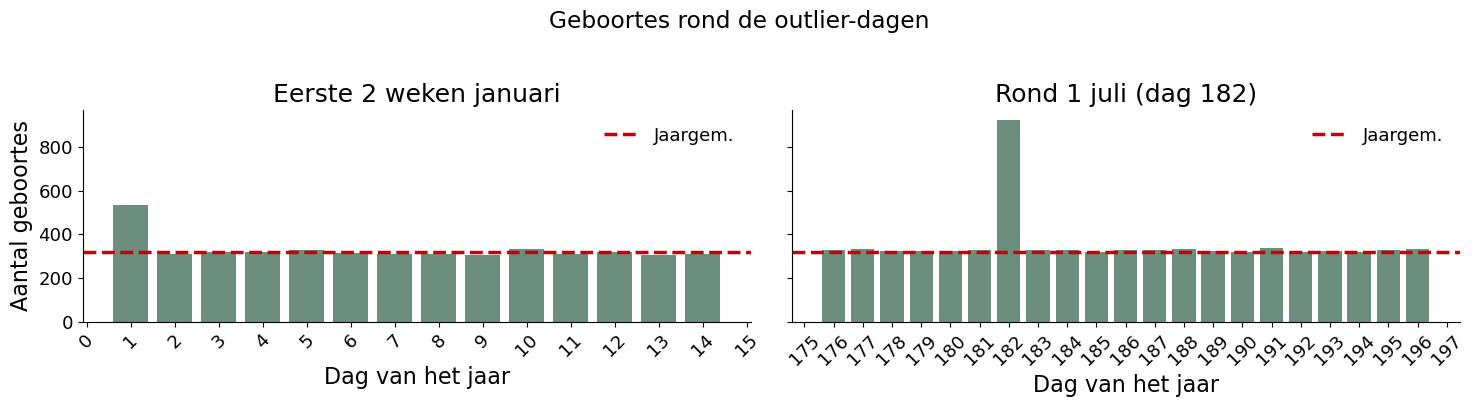

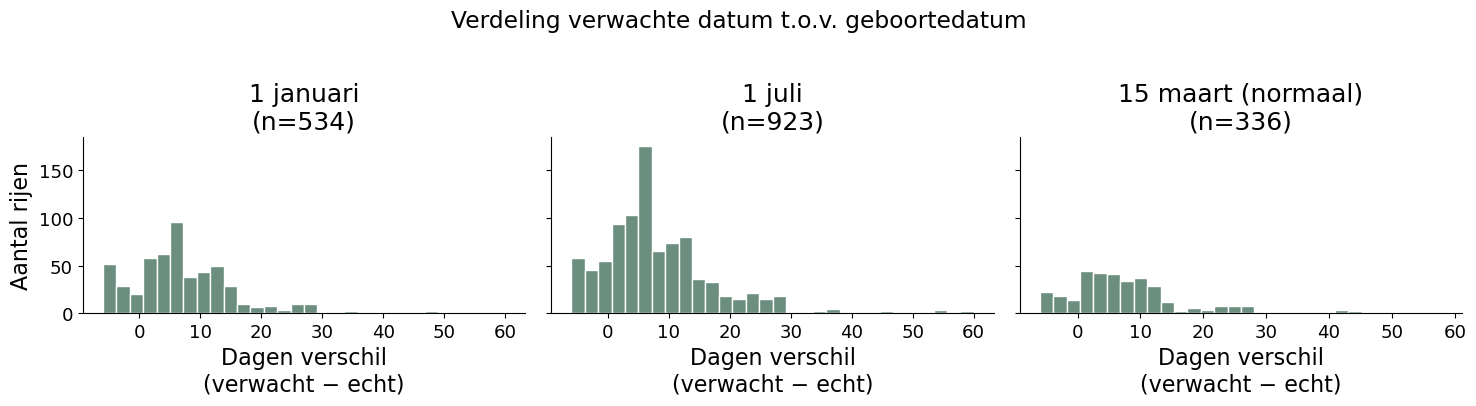

In [ ]:
# Check op aantal geboortes op de omliggende dagen 
# Als rijen van naburige dagen naar 1 jan / 1 jul verschoven zijn, zien we een piek op de outlier een dal(letje) eromheen

fig, axes = plt.subplots(1, 2, figsize=(15, 4), sharey=True)

for ax, (start, end, title) in zip(axes, [
    (1, 14, "Eerste 2 weken januari"),
    (176, 196, "Rond 1 juli (dag 182)"),
]):
    subset = daily[(daily["dag_van_jaar"] >= start) & (daily["dag_van_jaar"] <= end)]
    ax.bar(subset["dag_van_jaar"], subset["geboortes"], color=SAGE)
    ax.axhline(gemiddelde_geboortes, color=MEAN_COLOR, linestyle="--", label="Jaargem.")
    ax.set_title(title)
    ax.set_xlabel("Dag van het jaar")
    ax.xaxis.set_major_locator(plt.MultipleLocator(1))
    ax.tick_params(axis="x", labelrotation=45)
    ax.legend()

axes[0].set_ylabel("Aantal geboortes")

plt.suptitle("Geboortes rond de outlier-dagen", y=1.02)
plt.tight_layout()
plt.show()

# Check: de verdeling verwachte_datum op outlier vs normale dag
# Als de outlier-dag "vreemde" rijen bevat, zou de verwachte_datum-verdeling er anders uit dan op een normale dag.

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

normal_day = pd.Timestamp("2019-03-15")

for ax, (label, geboortedatum) in zip(axes, [
    ("1 januari", pd.Timestamp("2019-01-01")),
    ("1 juli", pd.Timestamp("2019-07-01")),
    ("15 maart (normaal)", normal_day),
]):
    dag = df_births[df_births[COL_GEBOORTEDATUM] == geboortedatum]
    verschil = (dag[COL_VERWACHTE_DATUM] - dag[COL_GEBOORTEDATUM]).dt.days
    ax.hist(verschil, bins=30, color=SAGE, edgecolor="white")
    ax.set_title(f"{label}\n(n={len(dag)})")
    ax.set_xlabel("Dagen verschil\n(verwacht − echt)")
    ax.xaxis.set_major_locator(plt.MultipleLocator(10))

axes[0].set_ylabel("Aantal rijen")
plt.suptitle("Verdeling verwachte datum t.o.v. geboortedatum", y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Er zijn niet minder geboortes rond de outlierdagen
# Er zit een zeer gelijkaardig patroon in de outlierdagen. Het patroon op een normale dag is gelijkaardig, behalve dat er geen piek zit rond de 6 dagen verschil tss. verwachte en echte datum. Maar dat zegt niks. 

#### Conclusie van checks op foute rijen in extreme outliers
Ik heb nagekeken: 
- of er duplicate rijen zijn in de outlier files
- of er duplicate rijen zijn als je de verwachte geboortedatum niet meeneemt
- of er duplicate rijen zijn als je de gemeente niet meeneemt
- of er beduidend minder geboortes zijn in de dagen rondom de outlier-date om te zien of er rows van de ene datum in de file van de andere zitten
- het patroon van verschil tussen verwachte datum en echte geboortedatum - dit is het enige waar iets opvalt: het distributie patroon is heel gelijkaardig in de 2 outlier-files, het gemiddelde verschil ligt dicht bij elkaar (maar is niet gelijk) en de minimum-afwijking en de maximum-afwijking zijn precies hetzelfde. Dat is raar, maar ik vind er verder niks op. 
- of er een mix is tussen de outlier-file 2019-7-1 en file 2019-1-7

De 2 files zijn op de start van een halfjaar/semester, 1 januari en 1 juli. Het lijkt of het een aggregaat is van meerdere maanden. Maar het zijn geen rijen uit andere files. 
Ik heb niks gevonden waarvan ik denk dat het zo afwijkend is dat ik zou zeggen: dit is het patroon. 

Daarom besluit ik om de files van 1 januari en 1 juli niet verder mee te nemen in de analyse. 

In [15]:
# Dus: we gooien geboortedatum 1 januari en 1 juli eruit

# # The two dates to isolate/remove
dates_to_flag = pd.to_datetime(["2019-01-01", "2019-07-01"])

# Mask for the rows we consider "wrong" (the two outlier dates)
mask_wrong = df_births[COL_GEBOORTEDATUM].isin(dates_to_flag)

# 1) All rows on those two dates
df_wrong = df_births.loc[mask_wrong].copy()

# 2) Clean dataframe with those dates removed
df_births_clean = df_births.loc[~mask_wrong].copy()

only_flag_in_wrong = df_wrong[COL_GEBOORTEDATUM].isin(dates_to_flag).all()
none_flag_in_clean = (~df_births_clean[COL_GEBOORTEDATUM].isin(dates_to_flag)).all()

# Sanity checks
assert len(df_births) == len(df_wrong) + len(df_births_clean), f"Length of df_wrong and length of df_births_clean do not sum up to length of df_births"
assert only_flag_in_wrong, (
    "df_wrong contains rows with dates not in dates_to_flag."
)
assert none_flag_in_clean, (
        "df_births_clean still contains dates_to_flag rows."
)
print("Asserts passed succesfully")
print("Number of wrong rows:",f"\n{df_wrong[COL_GEBOORTEDATUM].value_counts()}")
print("Total number of wrong rows:", len(df_wrong))
print("Clean rows:", len(df_births_clean))
print("Total rows in df_births", len(df_births))

Asserts passed succesfully
Number of wrong rows: 
geboortedatum
2019-07-01    923
2019-01-01    534
Name: count, dtype: int64
Total number of wrong rows: 1457
Clean rows: 115393
Total rows in df_births 116850


Opmerking KLA: de rode stippellijn op de grafiek van de voorbeeldoplossing kan niet het gemiddelde zijn. Ze ligt lager dan de meeste datapunten.

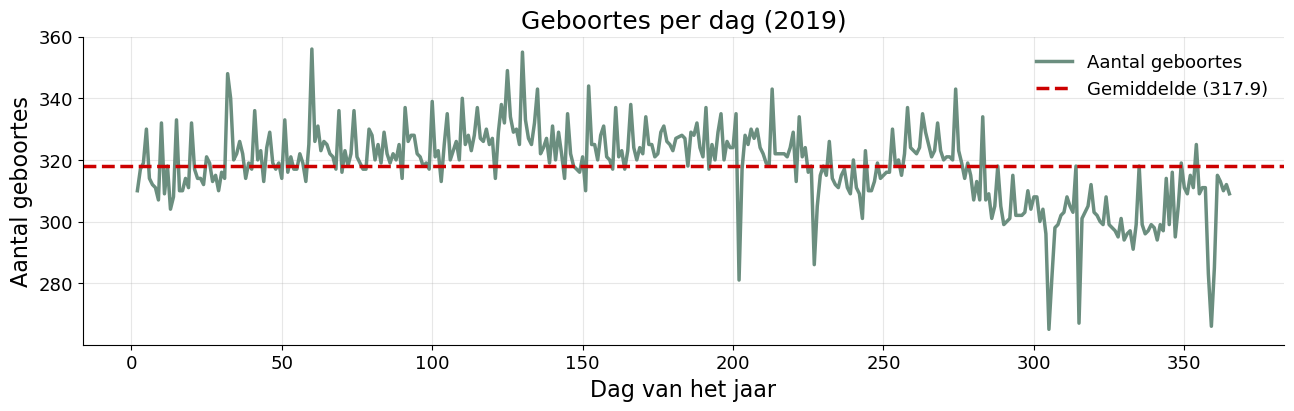

In [16]:
df_clean = df_births_clean.copy()
daily_clean = (
    df_clean
    .groupby("dag_van_jaar", as_index=False)
    .size()
    .rename(columns={"size": "geboortes"})
    .sort_values("dag_van_jaar")     
)

gemiddelde_geboortes = daily_clean["geboortes"].mean()

fig, ax = plt.subplots(figsize=(15.5, 4))
ax.plot(daily_clean["dag_van_jaar"], daily_clean["geboortes"], label = "Aantal geboortes")

ax.set_title("Geboortes per dag (2019)")
ax.set_xlabel("Dag van het jaar")
ax.set_ylabel("Aantal geboortes")

# 1) Set y-limits (bottom ≈ 250, top ≈ 360)
ax.set_ylim(260, 360)

# 2) Build tick list: ensure 280 is present, then the rest every 10 up to 360
ticks = list(range(280, 361, 20))

# 3) Apply ticks & integer formatting
ax.set_yticks(ticks)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%d'))

ax.grid(True, alpha=0.3)

# Horizontal dashed mean line
ax.axhline(
    y=gemiddelde_geboortes,
    color=MEAN_COLOR,
    linestyle="--",
    label=f"Gemiddelde ({gemiddelde_geboortes:.1f})"
)

ax.legend()
plt.show()

#### Vraag 2.3 Identificeer de **8 meest extreme** dagen in de tweede helft van het jaar. (1 pnt)

In [17]:
start = pd.Timestamp(f"2019-01-01")

# Controleer daily_clean
assert daily_clean["dag_van_jaar"].between(1, 365).all(), "dag_van_jaar buiten [1..365]"
assert daily_clean["dag_van_jaar"].is_unique, "dag_van_jaar bevat duplicaten"

# 2) Voeg datum (geboortedatum) toe aan daily_clean, en noem dat "dately"
dately = daily_clean.assign(
    geboortedatum = start + pd.to_timedelta(daily_clean["dag_van_jaar"] - 1, unit="D")
)

# Kolomvolgorde als in oplossing
dately = dately[["geboortedatum", "dag_van_jaar", "geboortes"]]

# Filter enkel tweede helft van het jaar (sem2)
start = pd.Timestamp("2019-07-01")
sem2 = dately[dately[COL_GEBOORTEDATUM] >= start]     

# 8 laagste dagtotalen, + nette kolommen met assign
extreme8 = sem2.nsmallest(8, "geboortes").sort_values("geboortedatum", ascending = True) #de 8 kleinste, in oplossing zijn het de kleinste uitschieters

display(extreme8)


,geboortedatum,dag_van_jaar,geboortes
199,2019-07-21,202,281
224,2019-08-15,227,286
302,2019-11-01,305,265
303,2019-11-02,306,282
312,2019-11-11,315,267
355,2019-12-24,358,283
356,2019-12-25,359,266
357,2019-12-26,360,285


### Vraag 3: Verbanden per week/maand

#### Vraag 3.1 (2 pnt)
We zien vele pieken en dalen in de evolutie van het aantal geboortes. We willen deze grafiek graag iets "gladder" maken. Kan je hiervoor eens een visualizatie maken van het **gemiddeld** aantal geboortes per week (dit voor elke week, dus maandag-maandag, dinsdag-dinsdag, woensdag-woensdag, ...).


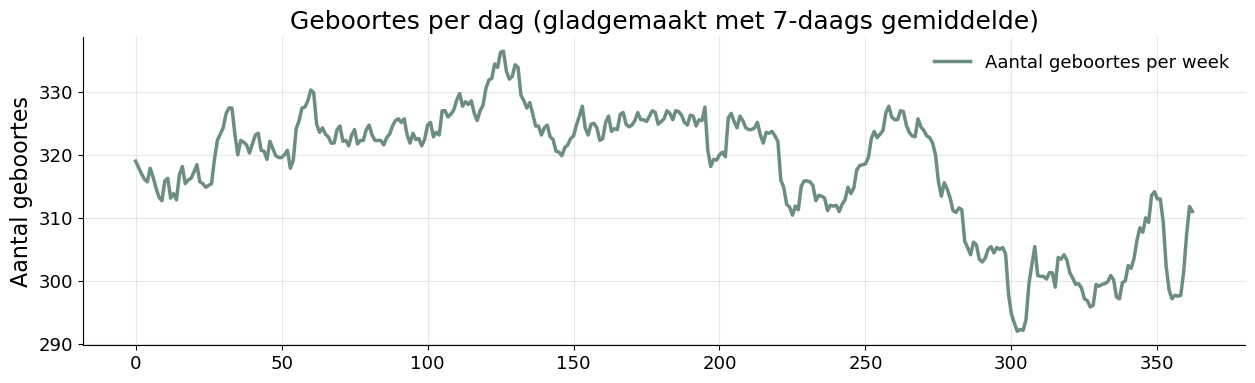

In [20]:
# 7-daags rolling average
ra7 = daily_clean["geboortes"].rolling(window=7, center=True, min_periods=3).mean()

fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(ra7.index, ra7.values, label="Aantal geboortes per week")
ax.set(title="Geboortes per dag (gladgemaakt met 7-daags gemiddelde)", ylabel="Aantal geboortes")
ax.grid(True, alpha=0.3); ax.legend()
plt.show()

#### Vraag 3.2 (2 pnt)
Dat ziet er al een stuk mooier uit!  We zien ook een aantal duidelijk dips & pieken verschijnen die we eerder niet zagen. We kunnen nu ook even kijken naar het gemiddeld aantal geboortes per dag van de week! Misschien worden er wel gewoon veel minder mensen geboren op zondag dan een andere dag?

Opmerking KLA: de grafiek in voorbeeldoplossing, is niet op gemiddelde maar op totaal aantal geboortes, de y-as gaat dat 16000, dat is geen gemiddelde.

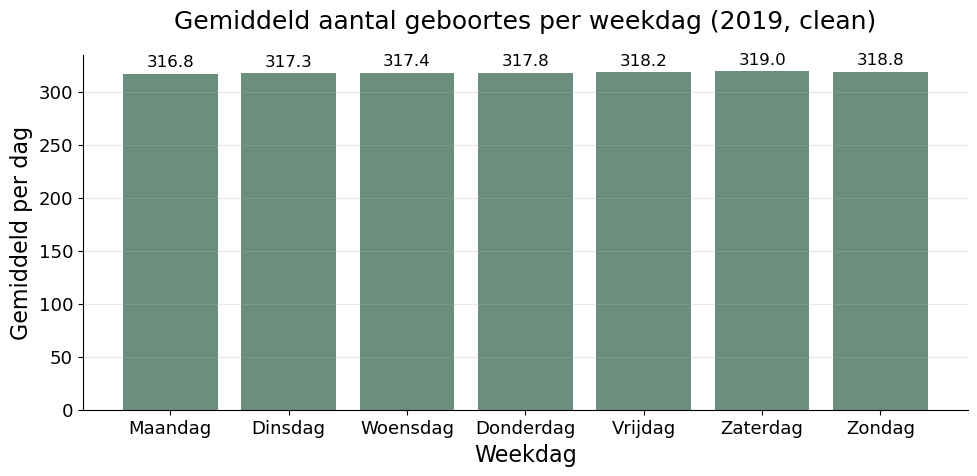

In [22]:
# Voeg kolom "weekdag" toe aan dately - eerst copy van dately en die noem ik dately_wd
dately_wd = dately.copy()

# Weekdagnaam uit kolom
try:
    dately_wd["weekdag"] = dately["geboortedatum"].dt.day_name(locale="nl_BE")
except Exception:
    dately_wd["weekdag"] = dately["geboortedatum"].dt.dayofweek.map({
        0:"Maandag",1:"Dinsdag",2:"Woensdag",3:"Donderdag",4:"Vrijdag",5:"Zaterdag",6:"Zondag"
    })

# Gemiddelde per weekdag
means = (dately_wd
         .groupby("weekdag", as_index=True)["geboortes"]
         .mean()
         .reindex(["Maandag","Dinsdag","Woensdag","Donderdag","Vrijdag","Zaterdag","Zondag"]))

# Plot
fig, ax = plt.subplots()
bars = ax.bar(means.index, means.values, color=SAGE)

ax.bar_label(bars, labels=[f"{v:.1f}" for v in means.values],
             padding=3, fontsize=12, color="black")

ax.set_title("Gemiddeld aantal geboortes per weekdag (2019, clean)", y=1.05)
ax.set_xlabel("Weekdag")
ax.set_ylabel("Gemiddeld per dag")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


#### Vraag 3.3 — Maandverschillen in geboortes (3pnt)

Je beschikt over geboortecijfers per dag voor één kalenderjaar.

Maak één visualisatie die het gemiddeld aantal geboortes per maand toont
en tegelijk toelaat om de variatie binnen elke maand te vergelijken.

De visualisatie moet:
- de maanden tonen in chronologische volgorde (januari → december)
- per maand het gemiddelde aantal geboortes tonen
- per maand de onzekerheid rond dat gemiddelde tonen op 95% betrouwbaarheid en gebaseerd op de dagwaarden (niet handmatig berekend)



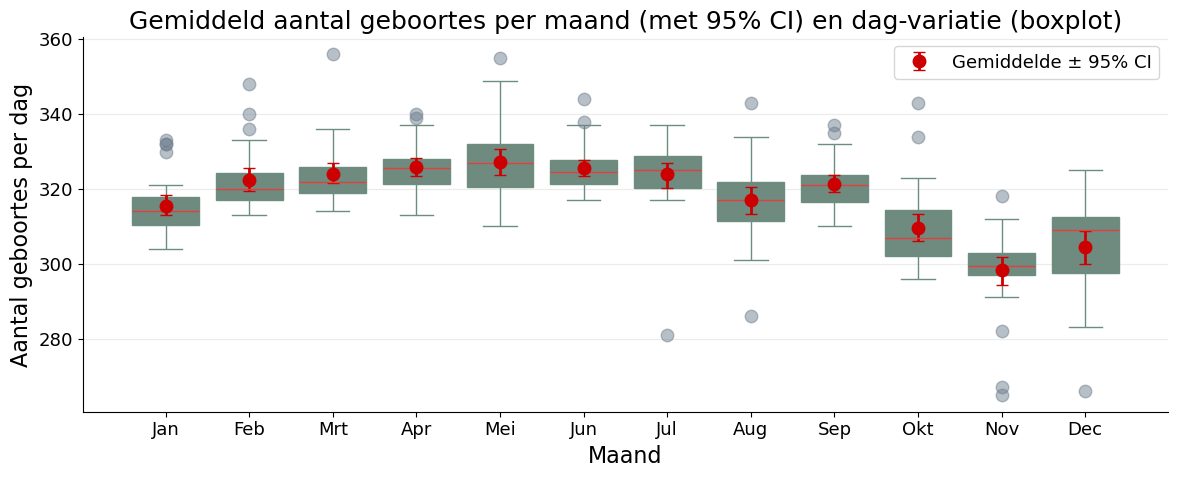

In [23]:
# Voeg kolom met nr, naam en korte naam van de maand toe in monthly; begin met copy, start van dately en niet van dately_wd, weekday heb je niet nodig
monthly= dately.copy()

monthly["maand_nr"]  = monthly[COL_GEBOORTEDATUM].dt.month

monthly["maand"] = monthly[COL_GEBOORTEDATUM].dt.month_name(locale="nl_BE") if hasattr(monthly[COL_GEBOORTEDATUM].dt, "month_name") else monthly[COL_GEBOORTEDATUM].dt.month.map({1:"Januari",2:"Februari",3:"Maart",4:"April",5:"Mei",6:"Juni",7:"Juli",8:"Augustus",9:"September",10:"Oktober",11:"November",12:"December"})

monthly["maand_kort"] = monthly["maand"].map({"Januari": "Jan","Februari": "Feb","Maart": "Mrt","April": "Apr","Mei": "Mei","Juni": "Jun","Juli": "Jul","Augustus":"Aug","September": "Sep","Oktober": "Okt","November": "Nov","December": "Dec"})

# Bootstrap 95% CI per maand op basis van de dagwaarden
def bootstrap_mean_ci(x, n_boot=5000, ci=0.95, random_state=42):
    rng = np.random.default_rng(random_state)
    x = np.asarray(x, dtype=float)
    boot = rng.choice(x, size=(n_boot, x.size), replace=True).mean(axis=1)
    lower = np.quantile(boot, (1-ci)/2)
    upper = np.quantile(boot, 1-(1-ci)/2)
    return x.mean(), lower, upper

ci_rows = []
for m, grp in monthly.groupby("maand_nr"):
    mu, lo, hi = bootstrap_mean_ci(grp["geboortes"].values, n_boot=5000, ci=0.95, random_state=2024+m)
    ci_rows.append({
        "maand_nr": m,
        "maand_kort": grp["maand_kort"].iloc[0],
        "mean": mu,
        "ci_low": lo,
        "ci_high": hi
    })

ci_df = (pd.DataFrame(ci_rows)
           .sort_values("maand_nr")
           .reset_index(drop=True))

# Visualisatie:
#    - Boxplot per maand (dagwaarden) => variatie zichtbaar
#    - Overlay: punt = maandgemiddelde + errorbar = 95% CI
#    - Maanden in chronologische volgorde

order_names = ci_df["maand_kort"].tolist()  # Jan -> Dec

fig, ax = plt.subplots(figsize=(12, 5))

# Boxplots per maand (dagelijks aantal geboortes)
sns.boxplot(
    data=monthly,
    x="maand_kort",
    y="geboortes",
    order=order_names,
    ax=ax,
    color=SAGE,
    boxprops=dict(edgecolor=SAGE), # lijn rond de box
    medianprops=dict(color=MEDIAN_COLOR),
    whiskerprops=dict(color=SAGE), #lijn van de whisker
    capprops=dict(color=SAGE),  # horizontale lijnen op het einde van de whisker
    flierprops=dict(markerfacecolor=SLATE, markeredgecolor=SLATE, alpha=0.5)
)

# Overlay: mean + 95% CI (errorbars)
xpos = np.arange(len(ci_df))
ax.errorbar(
    xpos, ci_df["mean"],
    yerr=[ci_df["mean"] - ci_df["ci_low"], ci_df["ci_high"] - ci_df["mean"]],
    fmt="o", color=MEAN_COLOR, ecolor=MEAN_COLOR, elinewidth=2, capsize=4, label="Gemiddelde ± 95% CI"
)

# X-as omzetten naar de maandlabels op dezelfde posities
ax.set_xticks(xpos, order_names, rotation=0)

ax.set_title("Gemiddeld aantal geboortes per maand (met 95% CI) en dag-variatie (boxplot)")
ax.set_xlabel("Maand")
ax.set_ylabel("Aantal geboortes per dag")
ax.grid(axis="y", alpha=0.25)
ax.legend(frameon = True)

plt.tight_layout()
plt.show()


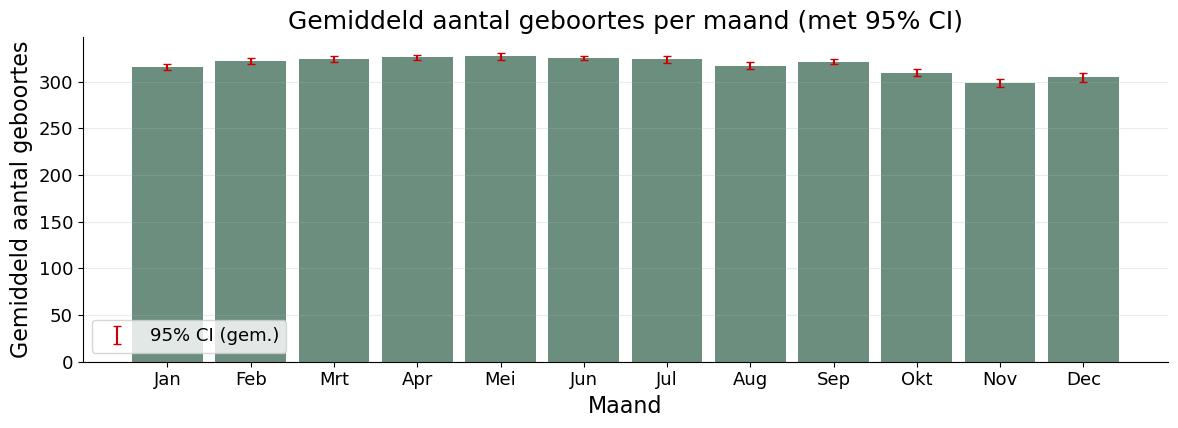

In [ ]:
# De plot namaken die in de opgave zit - is geen boxplot, maar een barchart met het betrouwbaarheidsinterval op de bars getekend. 
# Maandgemiddelde + 95% CI (t-interval) op basis van dagwaarden
try:
    from scipy.stats import t
    def tcrit(n):
        return t.ppf(0.975, df=n-1) if n > 1 else np.nan
except Exception:
    # Fallback: normal approximation (n≈30 → vrijwel gelijk)
    def tcrit(n):
        return 1.96 if n > 1 else np.nan

monthly_gr_agg= (monthly
           .groupby(["maand_nr", "maand_kort"], as_index=False)["geboortes"]
           .agg(n="count", mean="mean", std="std"))

monthly_gr_agg["sem"]   = monthly_gr_agg["std"] / np.sqrt(monthly_gr_agg["n"])
monthly_gr_agg["tcrit"] = monthly_gr_agg["n"].apply(tcrit)
monthly_gr_agg["ci_low"]  = monthly_gr_agg["mean"] - monthly_gr_agg["tcrit"] * monthly_gr_agg["sem"]
monthly_gr_agg["ci_high"] = monthly_gr_agg["mean"] + monthly_gr_agg["tcrit"] * monthly_gr_agg["sem"]

monthly_gr_agg = monthly_gr_agg.sort_values("maand_nr")

# Plot: bars + 95% CI 
x = np.arange(len(monthly_gr_agg))
y = monthly_gr_agg["mean"].values
yerr = np.vstack([y - monthly_gr_agg["ci_low"].values, monthly_gr_agg["ci_high"].values - y])

fig, ax = plt.subplots(figsize=(12, 4.5))

bars = ax.bar(x, y, width=0.85)  
ax.errorbar(x, y, yerr=yerr, fmt="none", ecolor=MEAN_COLOR,
            elinewidth=1.5, capsize=3, zorder=3, label="95% CI (gem.)")

ax.set_xticks(x, monthly_gr_agg["maand_kort"].tolist())
ax.set_title("Gemiddeld aantal geboortes per maand (met 95% CI)")
ax.set_xlabel("Maand")
ax.set_ylabel("Gemiddeld aantal geboortes")
ax.grid(axis="y", alpha=0.25)
ax.legend(frameon = True)

plt.tight_layout()
plt.show()

#### Vraag 3.2 Weekdag en seizoen (4 pnt)

Je beschikt over geboortecijfers per dag voor één kalenderjaar.

Onderzoek of het effect van de dag van de week op het aantal geboortes constant is doorheen het jaar of verschilt naargelang het seizoen.

Maak één visualisatie die:
- verschillen tussen weekdagen toont
- toelaat om deze verschillen over het jaar te vergelijken
- leesbaar blijft zonder aparte grafieken per maand of weekdag



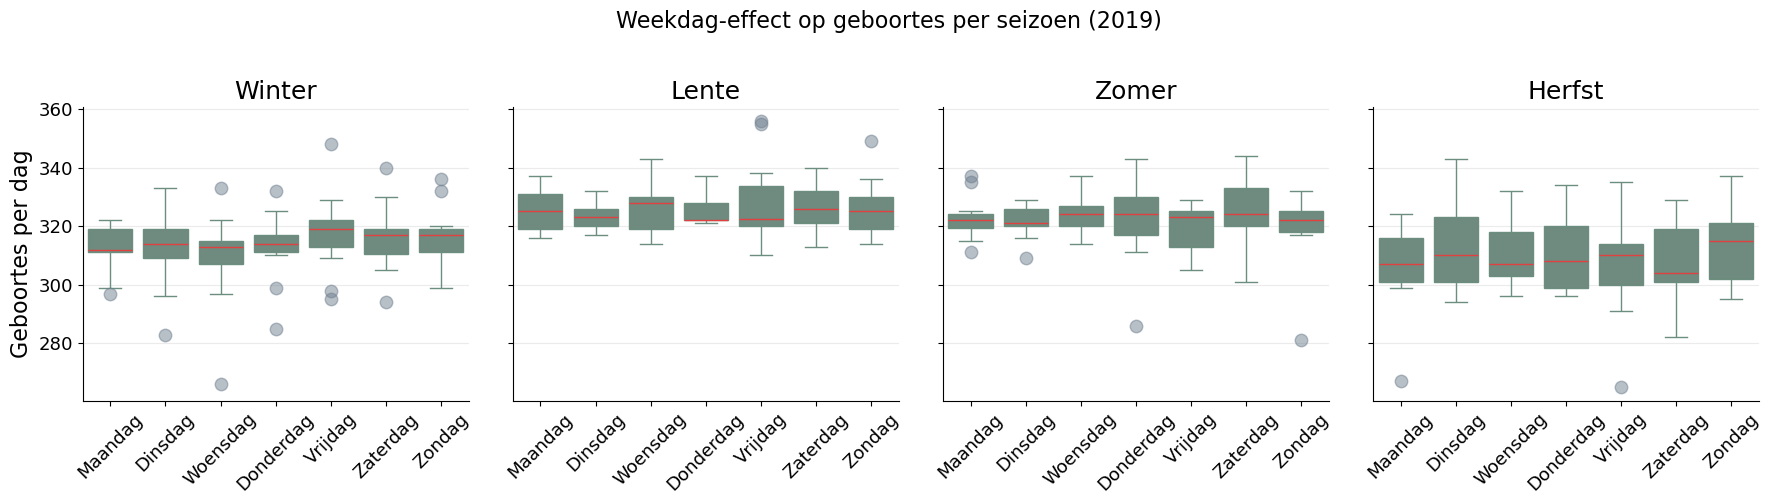

In [20]:
# 1) Voeg weekdag en seizoen toe aan dately
seasonal = dately.copy()

try:
    seasonal["weekdag"] = seasonal["geboortedatum"].dt.day_name(locale="nl_BE")
except Exception:
    seasonal["weekdag"] = seasonal["geboortedatum"].dt.dayofweek.map({
        0:"Maandag",1:"Dinsdag",2:"Woensdag",3:"Donderdag",4:"Vrijdag",5:"Zaterdag",6:"Zondag"
    })

month = seasonal["geboortedatum"].dt.month
seasonal["seizoen"] = np.select(
    [month.isin([3, 4, 5]),
     month.isin([6, 7, 8]),
     month.isin([9, 10, 11])],
    ["Lente", "Zomer", "Herfst"],
    default="Winter"
)

# Volgorde voor weekdagen en seizoenen
weekdag_order = ["Maandag", "Dinsdag", "Woensdag", "Donderdag", "Vrijdag", "Zaterdag", "Zondag"]
seizoen_order = ["Winter", "Lente", "Zomer", "Herfst"]

# 2) 1*4 subplots, één boxplot per seizoen, op 1 rij
fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=True)

# for ax, seizoen in zip(axes.flat, seizoen_order): voor 2x2subplots
for i, (ax, seizoen) in enumerate(zip(axes.flat, seizoen_order)):
    data_s = seasonal[seasonal["seizoen"] == seizoen]
    sns.boxplot(
        data=data_s,
        x="weekdag",
        y="geboortes",
        order=weekdag_order,
        ax=ax,
        color=SAGE,
        boxprops=dict(edgecolor=SAGE),
        medianprops=dict(color=MEDIAN_COLOR),
        whiskerprops=dict(color=SAGE),
        capprops=dict(color=SAGE),
        flierprops=dict(markerfacecolor=SLATE, markeredgecolor=SLATE, alpha=0.5)
    )
    ax.set_title(seizoen)
    ax.set_xlabel("")
    # ax.set_ylabel("Geboortes per dag" if ax in axes[:, 0] else "") # voor 2x2subplots 
    ax.set_ylabel("Geboortes per dag" if i == 0 else "")  # ← only first subplot
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", alpha=0.25)

fig.suptitle("Weekdag-effect op geboortes per seizoen (2019)", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

## Stap 3: Onderzoeksvragen


### Onderzoek 1: Unisex namen


#### Vraag 1.1 (3pnt)
Je wil namen identificeren die zowel bij jongens als bij meisjes voorkomen.
Construeer een tabel `df_name_gender` met exact één rij per naam, waarin je het totaal aantal geboortes voor jongens, voor meisjes en in totaal opneemt.

Rapporteer het aantal namen dat bij beide geslachten voorkomt en geef voor deze groep telkens de drie namen met het hoogste aantal jongensgeboortes, meisjesgeboortes en totale geboortes. Licht kort toe of en waarom je zeldzame namen al dan niet meeneemt in de analyse.


In [ ]:
# --- Vraag 1.1: Unisex namen ---

# 1) Eén rij per naam, met telling per geslacht
df_name_gender = (
    df_births_clean
    .groupby([COL_NAAM, COL_GESLACHT], as_index=False)
    .size()
    .pivot(index=COL_NAAM, columns=COL_GESLACHT, values="size")
    .fillna(0)
    .astype(int)
)

# Hernoem kolommen naar leesbare namen
df_name_gender.columns.name = None
df_name_gender = df_name_gender.rename(columns={"Mannelijk": "jongens", "Vrouwelijk": "meisjes"})
df_name_gender["totaal"] = df_name_gender["jongens"] + df_name_gender["meisjes"]
df_name_gender = df_name_gender.reset_index()

display(df_name_gender.head(10))

# 2) Namen die bij BEIDE geslachten voorkomen
df_unisex = df_name_gender[(df_name_gender["jongens"] > 0) & (df_name_gender["meisjes"] > 0)].copy()
print(f"Aantal namen bij beide geslachten: {len(df_unisex)}")

# 3) Top 3 per categorie
top3_jongens = df_unisex.nlargest(3, "jongens")[[COL_NAAM, "jongens"]]
top3_meisjes = df_unisex.nlargest(3, "meisjes")[[COL_NAAM, "meisjes"]]
top3_totaal  = df_unisex.nlargest(3, "totaal")[[COL_NAAM, "totaal"]]

print("Top 3 unisex namen – meeste jongensgeboortes:")
display(top3_jongens)
print("Top 3 unisex namen – meeste meisjesgeboortes:")
display(top3_meisjes)
print("Top 3 unisex namen – meeste geboortes totaal:")
display(top3_totaal)



,naam,jongens,meisjes,totaal
0,Aaron,45,0,45
1,Aaya,0,1,1
2,Abbas,2,0,2
3,Abdallah,3,0,3
4,Abdel,5,0,5
5,Abdelali,2,0,2
6,Abdelaziz,19,0,19
7,Abdelbasset,1,0,1
8,Abdelfattah,1,0,1
9,Abdelghani,3,0,3


Aantal namen bij beide geslachten: 75
Top 3 unisex namen – meeste jongensgeboortes:


,naam,jongens
3355,Maxime,200
4191,Robin,181
949,Claude,165


Top 3 unisex namen – meeste meisjesgeboortes:


,naam,meisjes
1157,Dominique,229
794,Camille,160
2648,Kim,113


Top 3 unisex namen – meeste geboortes totaal:


,naam,totaal
1157,Dominique,389
3355,Maxime,206
4191,Robin,189


Antwoord op 'licht kort toe of en waarom je zeldzame namen al dan niet meeneemt':
Ik neem alle namen mee. 
Het gaat over het aantal namen dat bij beide geslachten voorkomt en van die namen wordt gekeken naar welke het meest populair zijn, bij jongens, bij meisjes en in totaal. 
De zeldzame namen die maar bij 1 geslacht voorkomen, komen alvast niet terecht in de df_unisex. 
Je zou ze al kunnen uitfilteren bij de df_name_gender, maar ik denk dat het hier niet relevant is om die bewerking te doen. 
In de stap na het maken van df_unisex zoek je naar de top-3 namen, dan raak je niet aan de meer zeldzame namen. 
Ook hier denk ik dat het niet relevant is om een bewerking te doen waarmee je die weg zou halen. 
Je zou dan ook nog moeten definiëren wat je zeldzaam noemt


In [91]:
# "Antwoord op 'licht kort toe of en waarom je zeldzame namen al dan niet meeneemt':
# Ik neem alle namen mee. \nHet gaat over het aantal namen dat bij beide geslachten voorkomt en van die namen wordt gekeken naar welke het meest populair zijn, bij jongens, bij meisjes en in totaal. \nDe zeldzame namen die maar bij 1 geslacht voorkomen, komen alvast niet terecht in de df_unisex. 
# Je zou ze al kunnen uitfilteren bij de df_name_gender, maar ik denk dat het hier niet relevant is om die bewerking te doen. 
# In de stap na het maken van df_unisex zoek je naar de top-3 namen, dan raak je niet aan de meer zeldzame namen. 
# Ook hier denk ik dat het niet relevant is om een bewerking te doen waarmee je die weg zou halen. 
# Je zou dan ook nog moeten definiëren wat je zeldzaam noemt"

#### Vraag 1.2 (2 pnt)

Niet alle namen die bij beide geslachten voorkomen, zijn evenwichtig verdeeld. In deze oefening beschouwen we een naam als “echt unisex” wanneer het aantal geboortes bij het ene geslacht niet meer dan 50% hoger ligt dan bij het andere. Concreet geldt voor een naam met `x` mannen en `y` vrouwen dat deze als echt unisex wordt beschouwd wanneer `x <= 1.5 * y` en `y <= 1.5 * x`.

Pas deze definitie toe op je unisex dataset en construeer een DataFrame `df_real_unisex` dat uitsluitend deze echte unisex namen bevat.

Beantwoord vervolgens opnieuw de drie vragen uit de vorige oefening voor deze dataset.


In [22]:
# --- Vraag 1.2: Echt unisex namen ---

# Filter: x <= 1.5*y EN y <= 1.5*x
df_real_unisex = df_unisex[
    (df_unisex["jongens"] <= 1.5 * df_unisex["meisjes"]) &
    (df_unisex["meisjes"] <= 1.5 * df_unisex["jongens"])
].copy().reset_index(drop=True).sort_values("totaal", ascending = False)

print(f"Aantal echte unisex namen: {len(df_real_unisex)}")
display(df_real_unisex)

# Top 3 per categorie
print("Top 3 echt unisex namen – meeste jongensgeboortes:")
display(df_real_unisex.nlargest(3, "jongens")[[COL_NAAM, "jongens"]])
print("Top 3 echt unisex namen – meeste meisjesgeboortes:")
display(df_real_unisex.nlargest(3, "meisjes")[[COL_NAAM, "meisjes"]])
print("Top 3 echt unisex namen – meeste geboortes totaal:")
display(df_real_unisex.nlargest(3, "totaal")[[COL_NAAM, "totaal"]])

Aantal echte unisex namen: 15


,naam,jongens,meisjes,totaal
3,Dominique,160,229,389
9,Noa,36,26,62
1,Charlie,6,4,10
5,Gabriele,6,4,10
2,Deniz,5,4,9
7,Joni,3,4,7
14,Yoni,3,3,6
6,Isa,3,2,5
8,Niki,2,3,5
10,Senna,2,3,5


Top 3 echt unisex namen – meeste jongensgeboortes:


,naam,jongens
3,Dominique,160
9,Noa,36
1,Charlie,6


Top 3 echt unisex namen – meeste meisjesgeboortes:


,naam,meisjes
3,Dominique,229
9,Noa,26
1,Charlie,4


Top 3 echt unisex namen – meeste geboortes totaal:


,naam,totaal
3,Dominique,389
9,Noa,62
1,Charlie,10


#### Vraag 1.3 (1 pnt)
Ga na of echte unisex namen relatief populairder zijn bij mannen of bij vrouwen, of dat de populariteit tussen beide geslachten vergelijkbaar is. Hiervoor kan je vertrekken van het percentage mannen en vrouwen dat een echte unisex naam draagt.

In [23]:
# --- Vraag 1.3: Zijn echte unisex namen populairder bij mannen of vrouwen? ---

# Totaal aantal jongens- en meisjesgeboortes in de volledige dataset
totaal_jongens = len(df_births_clean[df_births_clean[COL_GESLACHT] == "Mannelijk"])
totaal_meisjes = len(df_births_clean[df_births_clean[COL_GESLACHT] == "Vrouwelijk"])

# Aantal jongens/meisjes met een echt unisex naam
unisex_jongens = df_real_unisex["jongens"].sum()
unisex_meisjes = df_real_unisex["meisjes"].sum()

pct_jongens = unisex_jongens / totaal_jongens * 100
pct_meisjes = unisex_meisjes / totaal_meisjes * 100

print(f"Percentage mannen met unisex naam: {pct_jongens:.2f}%")
print(f"Percentage vrouwen met unisex naam: {pct_meisjes:.2f}%")


Percentage mannen met unisex naam: 0.40%
Percentage vrouwen met unisex naam: 0.50%


#### Vraag 1.4 (2 pnt)

Maak een visualizatie die alle echte unisex namen toont en de relatieve voorkomens bij mannen en vrouwen.

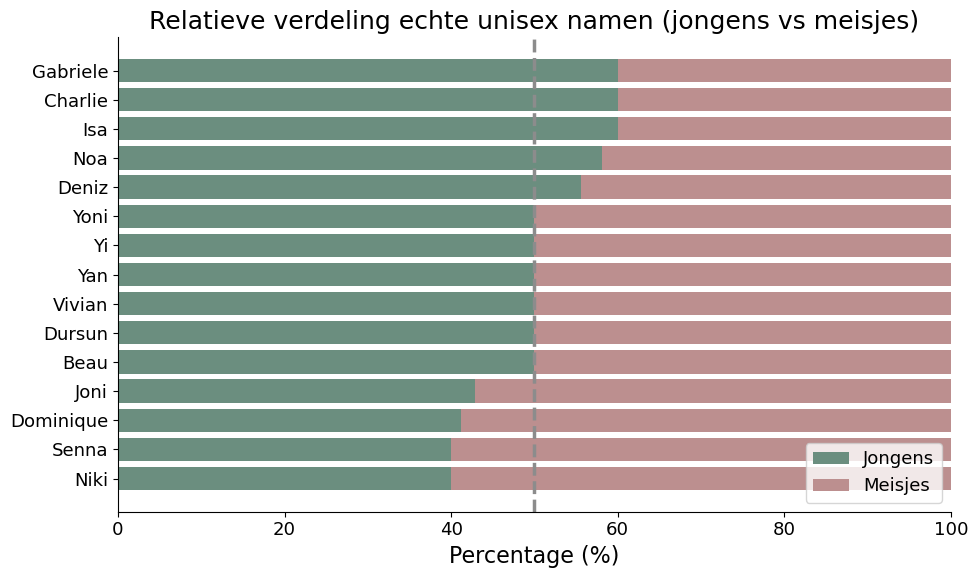

In [24]:
# --- Vraag 1.4: Visualisatie echte unisex namen ---
from syntradsexamen.styling import SAGE, ROSY

# Bereken relatieve aandelen
plot_df = df_real_unisex.copy().sort_values("totaal", ascending=True)
plot_df["pct_jongens"] = plot_df["jongens"] / plot_df["totaal"] * 100
plot_df["pct_meisjes"] = plot_df["meisjes"] / plot_df["totaal"] * 100

plot_df = plot_df.sort_values("pct_jongens", ascending=True)

fig, ax = plt.subplots(figsize=(10, max(4, len(plot_df) * 0.4)))

ax.barh(plot_df[COL_NAAM], plot_df["pct_jongens"], label="Jongens", color=SAGE)
ax.barh(plot_df[COL_NAAM], plot_df["pct_meisjes"], left=plot_df["pct_jongens"], label="Meisjes", color=ROSY)

# Verticale lijn op 50%
ax.axvline(50, color=GRAY, linestyle="--")

ax.set_xlabel("Percentage (%)")
ax.set_title("Relatieve verdeling echte unisex namen (jongens vs meisjes)")
ax.legend(loc="lower right", frameon = True)
ax.set_xlim(0, 100)

plt.tight_layout()
plt.show()


### Onderzoek 2: de accuraatheid van de geschatte bevallingsdatum


### Vraag 2.1 Evolutie vergelijken (3pnt)

Maak één figuur waarin je het totale aantal effectieve geboortes per dag en het totale aantal verwachte geboortes per dag samen weergeeft over de tijd.

Zorg ervoor dat beide reeksen op een eerlijke en vergelijkbare manier worden getoond.


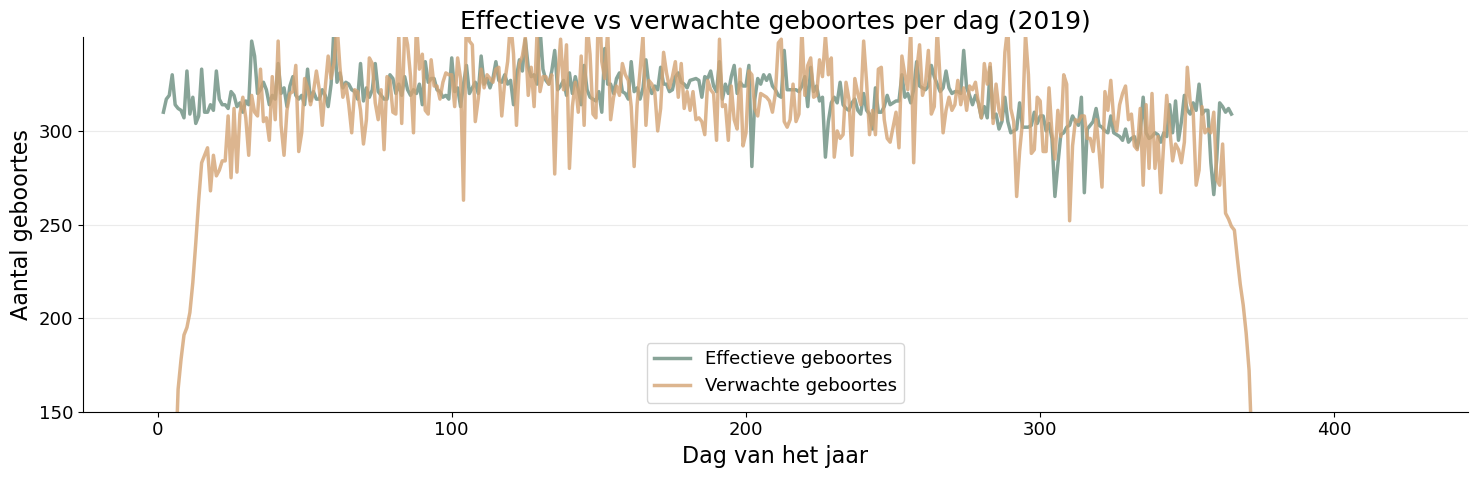

In [25]:
# --- Vraag 2.1: Effectieve vs verwachte geboortes per dag ---
from syntradsexamen.styling import SAGE, TAN

# 1) Effectieve geboortes per dag (reeds zonder 1 jan en 1 jul)
effectief = (
    df_births_clean
    .groupby(COL_GEBOORTEDATUM, as_index=False)
    .size()
    .rename(columns={"size": "effectief"})
    .sort_values(COL_GEBOORTEDATUM)
)
effectief["dag_van_jaar"] = effectief[COL_GEBOORTEDATUM].dt.dayofyear

# 2) Verwachte geboortes per dag — geen filter op jaar
start_2019 = pd.Timestamp("2019-01-01")
verwacht = (
    df_births_clean
    .groupby(COL_VERWACHTE_DATUM, as_index=False)
    .size()
    .rename(columns={COL_VERWACHTE_DATUM: "datum", "size": "verwacht"})
)
verwacht["dag_van_jaar"] = (verwacht["datum"] - start_2019).dt.days + 1
verwacht = verwacht.sort_values("dag_van_jaar")

# 3) Plot — twee aparte lijnen, geen merge
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(effectief["dag_van_jaar"], effectief["effectief"], label="Effectieve geboortes", color=SAGE, alpha=0.8)
ax.plot(verwacht["dag_van_jaar"], verwacht["verwacht"], label="Verwachte geboortes", color=TAN, alpha=0.8)

ax.set_title("Effectieve vs verwachte geboortes per dag (2019)")
ax.set_xlabel("Dag van het jaar")
ax.set_ylabel("Aantal geboortes")

# 1) Set y-limits (bottom ≈ 250, top ≈ 360)
ax.set_ylim(150, 350)

# 2) Build tick list: ensure 280 is present, then the rest every 10 up to 360
ticks = list(range(150, 350, 50))

# 3) Apply ticks & integer formatting
ax.set_yticks(ticks)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%d'))

ax.legend(frameon = True)
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()


#### Vraag 2.2 (1 pnt)
De figuur vertoont aan het begin en het einde van het jaar een afwijkend patroon. Beschrijf kort waarom dit gebeurt en noteer je verklaring in een comment

In [26]:
# Deze plot geeft de effectieve en verwachte geboortes onafhankelijk van elkaar weer. 
# Begin van de plot: Het aantal effectieve geboortes begint op 2 januari (omdat we 1 januari eruit gegooid hebben) met +-310 geboortes. De verwachte geboortes beginnen eerder dan 2 januari. Als je de y-as vanaf 0 zou tekenen ipv vanaf 150, dan zou je zien dat er dagen zijn die voor de 0 liggen, dat zijn dagen in 2018. Dat zijn er weinig, en omdat een lijnplot punten met elkaar verbindt, gaat die lijn omhoog naarmate er meer geboortes verwacht worden op een datum. 
# Einde van de plot: de laatste dag van het jaar heeft een aantal effectieve gebootes, ook +-310. Voor de verwachte geboortes zijn er ook nog data na 2019, want sommige baby's die al geboren zijn in 2019 werden pas verwacht in 2020. En dan loopt de lijn door tot na 365 dagen. Ook dat is een steeds kleiner wordend aantal en zo loopt die lijn ook weer steil naar beneden.

### Vraag 2.3 (3 pnt)

Voor het jaar 2019 wil je analyseren hoe vroeg baby’s effectief geboren worden ten opzichte van hun verwachte geboortedatum.

Definieer een foutmaat die het verschil uitdrukt tussen de effectieve en de verwachte geboortedag, waarbij positieve waarden overeenkomen met een geboorte vóór de verwachte datum. Beperk je analyse tot geboortes die effectief te vroeg plaatsvinden en visualiseer de verdeling van deze foutmaat voor 2019 in een histogram. Kies het aantal bins expliciet en motiveer kort waarom deze keuze geschikt is.

Duid in het histogram zowel de mediaan als het 90e percentiel van het aantal dagen te vroeg expliciet aan.


Mediaan dagen te vroeg: 7
P90 dagen te vroeg: 22


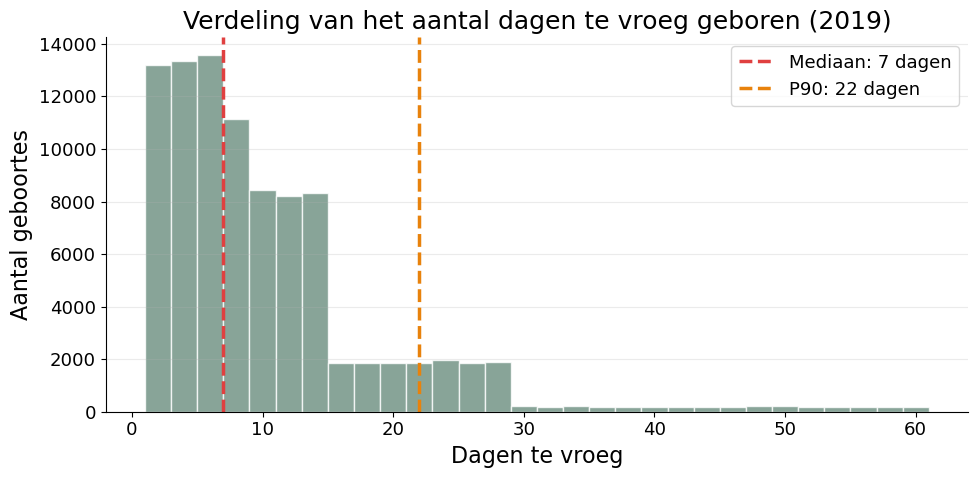

In [26]:
# 1) Foutmaat: verwachte datum - effectieve datum (positief = te vroeg geboren)
te_vroeg = df_births_clean[[COL_GEBOORTEDATUM, COL_VERWACHTE_DATUM]].copy()
te_vroeg["dagen_te_vroeg"] = (te_vroeg[COL_VERWACHTE_DATUM] - te_vroeg[COL_GEBOORTEDATUM]).dt.days

# 2) Alleen geboortes die effectief te vroeg plaatsvinden (dagen_te_vroeg > 0)
te_vroeg = te_vroeg[te_vroeg["dagen_te_vroeg"] > 0].copy()

# 3) Mediaan en P90
mediaan = te_vroeg["dagen_te_vroeg"].median()
p90 = te_vroeg["dagen_te_vroeg"].quantile(0.90)
print(f"Mediaan dagen te vroeg: {mediaan:.0f}")
print(f"P90 dagen te vroeg: {p90:.0f}")

# 4) Histogram
#    Max is typisch ~280 dagen; bins van 7 dagen (1 week) is intuïtief
#    en geeft voldoende detail zonder ruis
max_dagen = int(te_vroeg["dagen_te_vroeg"].max())
bins = range(1, max_dagen + 2, 2)

fig, ax = plt.subplots()

ax.hist(te_vroeg["dagen_te_vroeg"], bins=bins, color=SAGE, edgecolor="white", alpha=0.8)

ax.axvline(mediaan, color=MEDIAN_COLOR, linestyle="--",
           label=f"Mediaan: {mediaan:.0f} dagen")
ax.axvline(p90, color=P75_COLOR, linestyle="--", 
           label=f"P90: {p90:.0f} dagen")

ax.set_title("Verdeling van het aantal dagen te vroeg geboren (2019)")
ax.set_xlabel("Dagen te vroeg")
ax.set_ylabel("Aantal geboortes")
ax.legend(frameon = True)
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

### Vraag 2.4 (4 pnt)

Voor het jaar 2019 wil je nagaan hoe goed de verwachte geboortedag overeenkomt met de effectieve geboortedag, maar je wil dit nu enkel doen voor de acht gemeenten met het hoogste aantal geboortes.

Bepaal eerst welke acht gemeenten in 2019 de meeste geboortes tellen. Visualiseer vervolgens, voor deze acht gemeenten, de relatie tussen de effectieve dag van het jaar en de verwachte dag van het jaar in een scatterplot per gemeente, zodat je kan vergelijken of de accuraatheid verschilt tussen gemeenten.

Gebruik in alle deelplots dezelfde schaal op beide assen en voeg een referentielijn toe die een perfecte schatting voorstelt.


Top 8 gemeenten: ['Antwerpen', 'Gent', 'Charleroi', 'Luik', 'Brussel', 'Schaarbeek', 'Brugge', 'Anderlecht']
Aantal punten per gemeente (na dropna op verwachte datum):
  gemeente    n
 Antwerpen 5985
      Gent 3006
 Charleroi 2286
      Luik 2189
   Brussel 1926
Schaarbeek 1352
    Brugge 1342
Anderlecht 1292


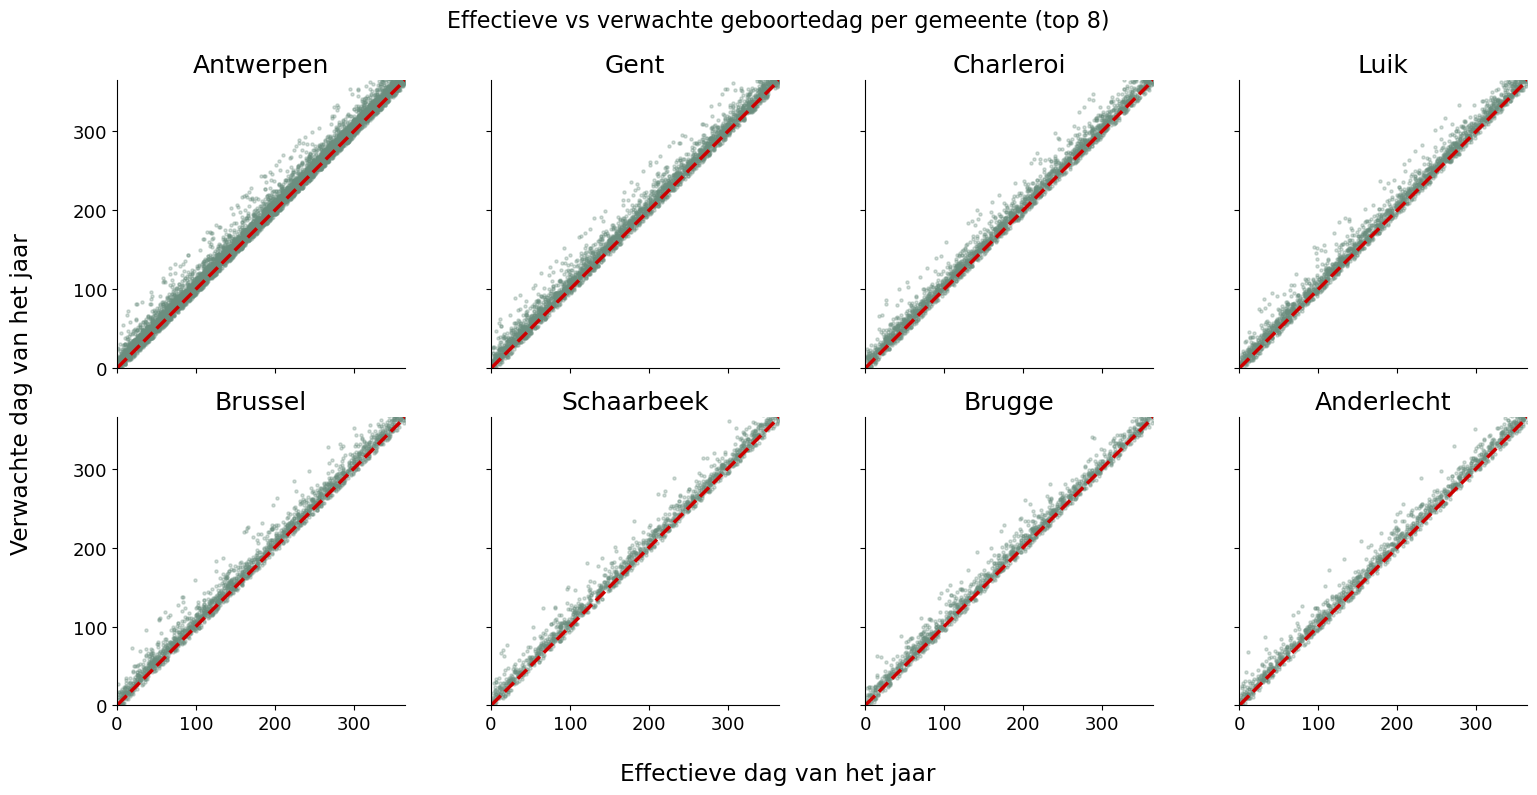

In [27]:
# 1) Top 8 gemeenten op aantal geboortes
top8 = (
    df_births_clean
    .groupby(COL_GEMEENTE, as_index=False)
    .size()
    .rename(columns={"size": "n"})
    .nlargest(8, "n")
)[COL_GEMEENTE].tolist()

print(f"Top 8 gemeenten: {top8}")

# 2) Subset met dag van het jaar voor effectief en verwacht
scatter_df = df_births_clean[df_births_clean[COL_GEMEENTE].isin(top8)].copy()
start_2019 = pd.Timestamp("2019-01-01")
scatter_df["effectieve_dag"] = (scatter_df[COL_GEBOORTEDATUM] - start_2019).dt.days + 1
scatter_df["verwachte_dag"] = (scatter_df[COL_VERWACHTE_DATUM] - start_2019).dt.days + 1

# Verwijder rijen zonder verwachte datum
scatter_df = scatter_df.dropna(subset=[COL_VERWACHTE_DATUM])

counts = (
    scatter_df.groupby(COL_GEMEENTE)
              .size()
              .reindex(top8, fill_value=0)  # zelfde volgorde als top8
              .rename("n")
              .reset_index()
)
print("Aantal punten per gemeente (na dropna op verwachte datum):")
print(counts.to_string(index=False))

# 3) 2x4 scatterplot
fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharex=True, sharey=True)

for ax, gemeente in zip(axes.flat, top8):
    data_g = scatter_df[scatter_df[COL_GEMEENTE] == gemeente]
    ax.scatter(data_g["effectieve_dag"], data_g["verwachte_dag"],
              alpha=0.3, s=5, color=SAGE)
    # Referentielijn: perfecte schatting (y = x)
    ax.plot([1, 365], [1, 365], color=MEAN_COLOR, linestyle="--")
    ax.set_title(gemeente)
    ax.set_aspect("equal")
  
    ax.set_xlim(0, 365)
    ax.set_ylim(0, 365)

# Gedeelde labels
fig.supxlabel("Effectieve dag van het jaar")
fig.supylabel("Verwachte dag van het jaar")
fig.suptitle("Effectieve vs verwachte geboortedag per gemeente (top 8)", fontsize=16)

plt.tight_layout()
plt.show()


### Onderzoek 3: Aantal namen versus aantal babies

#### Vraag 3.1

Wanneer er meer baby’s geboren worden, verwachten we ook meer verschillende namen te observeren. Bij lage aantallen geboortes lijkt het aannemelijk dat dit verband ongeveer lineair is, maar bij grotere aantallen wordt het minder vanzelfsprekend dat het aantal unieke namen in dezelfde mate blijft toenemen. We verwachten bijvoorbeeld niet dat het aantal unieke namen bij twee miljoen geboortes dubbel zo groot is als bij één miljoen geboortes.

Onderzoek op basis van deze dataset het verband tussen het aantal baby’s en het aantal unieke namen. Je krijgt geen suggestie voor een specifieke visualisatie en kiest zelf hoe je dit verband het best aantoont.

Onderbouw je antwoord met minstens één visualisatie en bijkomende analyse waar nodig. Probeer niet enkel te beschrijven wat je ziet, maar overtuig waarom jouw conclusie logisch is gegeven de data en waarom een lineair verband al dan niet houdbaar blijft over het volledige bereik.


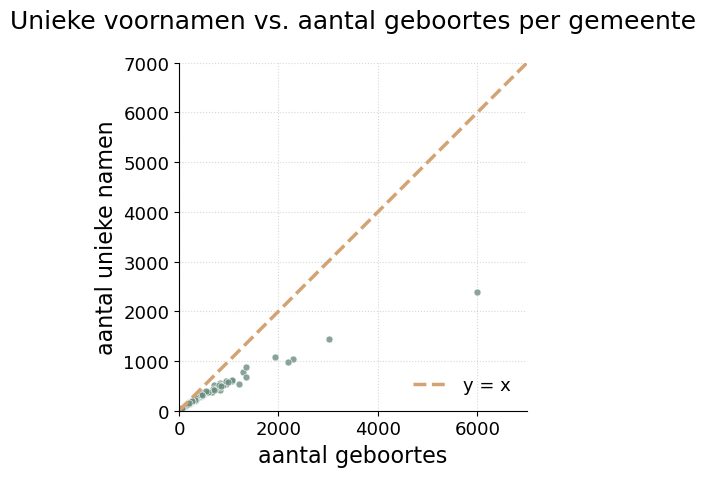

In [28]:
# --- Onderzoek 3: Aantal namen vs aantal babies ---
# Eerste verkenning: per gemeente
# Aanname: df_births_clean, COL_GEMEENTE en COL_NAAM bestaan al
import matplotlib.pyplot as plt

gemeente_stats = (
    df_births_clean
    .groupby(COL_GEMEENTE)
    .agg(geboortes=(COL_NAAM, "size"), unieke_namen=(COL_NAAM, "nunique"))
    .reset_index()
)

fig, ax = plt.subplots()  

fig.subplots_adjust(top=1.5)   

ax.scatter(
    gemeente_stats["geboortes"],
    gemeente_stats["unieke_namen"],
    s=25,
    alpha=0.8,
    edgecolor="white",
    linewidth=0.5
)

ax.set_xlabel("aantal geboortes")
ax.set_ylabel("aantal unieke namen")
ax.set_title("Unieke voornamen vs. aantal geboortes per gemeente", pad=25)

# Limieten zoals je had
ax.set_xlim(0, 7000)
ax.set_ylim(0, 7000)

# Hulplijn y=x voor referentie (maximaal mogelijke unieke-namen-lijn)
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()
lim = min(xmax, ymax)
ax.plot([0, lim], [0, lim], color=TAN, linestyle="--", label="y = x")

# Optioneel: gelijke as-schaal zodat 1 op x = 1 op y
ax.set_aspect('equal', adjustable='box')

ax.grid(True, linestyle=":", alpha=0.5)
ax.legend(loc="lower right")

fig.tight_layout()
plt.show()


#### Met random sampling

We nemen een aantal punten waarop we samples trekken 

In [29]:
# Random sampling: trek steeds grotere steekproeven en tel unieke namen
from tqdm import tqdm

rng = np.random.default_rng(42) # de random number generator - de machine die de random picking gaat doen 
all_names = df_births_clean[COL_NAAM].values
n_total = len(all_names)

# 100 sample sizes
sample_sizes = np.linspace(100, n_total, 100, dtype=int) # bepaal het aantal steekproven (100) en hoeveel er in elke steekproef gaat, gelijkmatig gespreid, dan bv. 1400, dan 2700 en zo tot je er 100 hebt - dus je krijgt hier een lijst met 100 getallen 

results = []
for n in tqdm(sample_sizes):
    sample = rng.choice(all_names, size=n, replace=False) # hier workt elke sample gemaakt - dus n namen opgepikt 
    num_names = len(np.unique(sample)) # hoeveel unieke namen zijn er in de sample 
    results.append({"geboortes": n, "unieke_namen": num_names}) # zet die 2 gegevens als een dict in de lijst results

df_samples = pd.DataFrame(results) # maak een df van de results ; heeft 3 kolommen geboortes, unieke_namen en freq_naam
df_samples["freq_naam"] = df_samples["geboortes"] / df_samples["unieke_namen"] # bereken de gemiddelde frequentie van elke unieke naam

100%|██████████| 100/100 [00:04<00:00, 21.72it/s]


We bekijken eerst rechstreeks het verband waar we geinteresseerd in zijn. Dit verband lijkt eerst sterk te stijgen maar vanaf 40 000 geboortes vlakt de stijging sterk af. Het verband is zeker niet linear, hoewel we vanaf de 40 000 wel van een min of meer lineair verband kunnen spreken. Om de rechte verder door te trekken, hebben we een grotere dataset nodig.

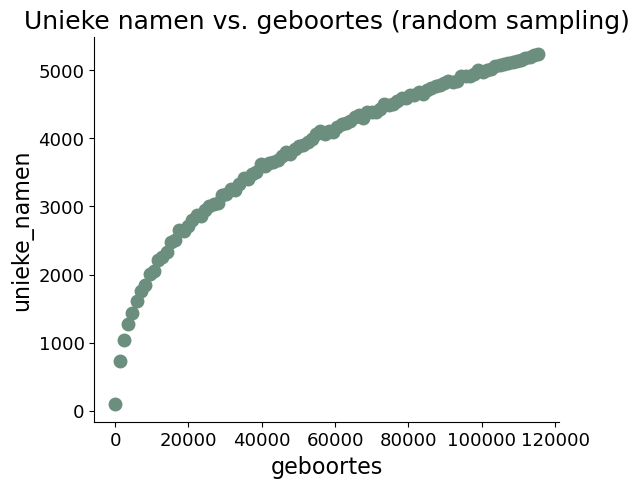

In [ ]:
# Verband tussen aantal unieke namen en aantal geboortes. 
fig, ax = plt.subplots(figsize =(6,5))
ax.scatter(df_samples["geboortes"], df_samples["unieke_namen"])
ax.set_xlabel("geboortes")
ax.set_ylabel("unieke_namen")
ax.set_title("Unieke namen vs. geboortes (random sampling)")
plt.show()

Een afgeleide variabele (die misschien wel interessanter is) is de frequentie van elke naam als functie van het aantal geboortes. Als we deze variabele nemen, zien we vrij snel een lineair verband ontstaan (hoewel voor minder dan 10 000 geboortes het verband niet echt lineair is). We kunnen dit verband tonen en een lineaire rechte fitten op het gedeelte met meer dan 10 000 geboortes.

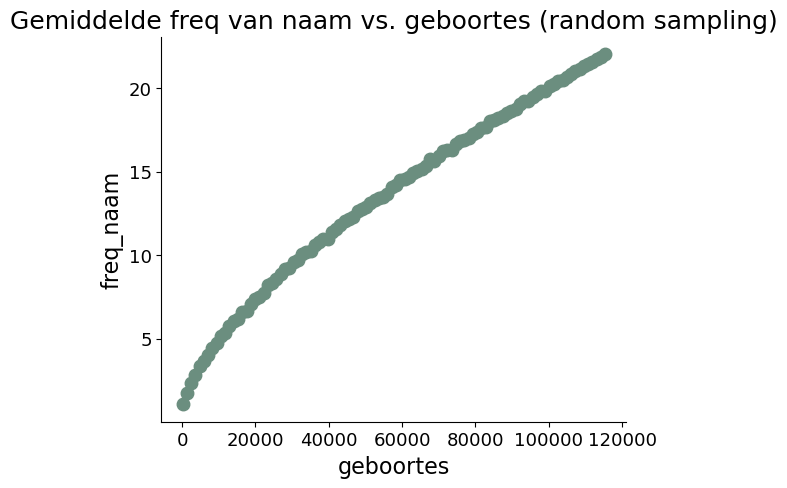

In [36]:
fig, ax = plt.subplots(figsize =(6,5))
ax.scatter(df_samples["geboortes"], df_samples["freq_naam"])
ax.set_xlabel("geboortes")
ax.set_ylabel("freq_naam")
ax.set_title("Gemiddelde freq van naam vs. geboortes (random sampling)")
plt.show()

### Lineaire regressie
We doen nu een lineaire regressie op de data voor `n_births > 10 000`

In [ ]:
# Lineaire regressie op freq_names voor n_births > 10 000
from sklearn.linear_model import LinearRegression as LR # importeer het Linear Regressie model uit sklearn

mask = df_samples["geboortes"] > 10_000 # maak een filter op de rijen met meer dan 10000 geboortes
X_train = df_samples.loc[mask, ["geboortes"]].values # de input, de brackets rond "geboortes" is omdat x-input 2D moet zijn voor scikit-learn
y_train = df_samples.loc[mask, "freq_naam"].values # de output, dit is wat je gaat voorspellen, moet een 1D list zijn 

reg = LR().fit(X_train, y_train) # het model - fit() zoekt de beste liujn door de punten y = intercept + coefficient * x 
print(f"Intercept: {reg.intercept_}") # intercept is waar de lijn de y-as kruist
print(f"Coefficient: {reg.coef_[0]}") # de helling van de lijn, hoeveel stijgt freq_naam als geboorte met 1 toeneemt


Intercept: 4.6522145852279095
Coefficient: 0.00015625465679705244


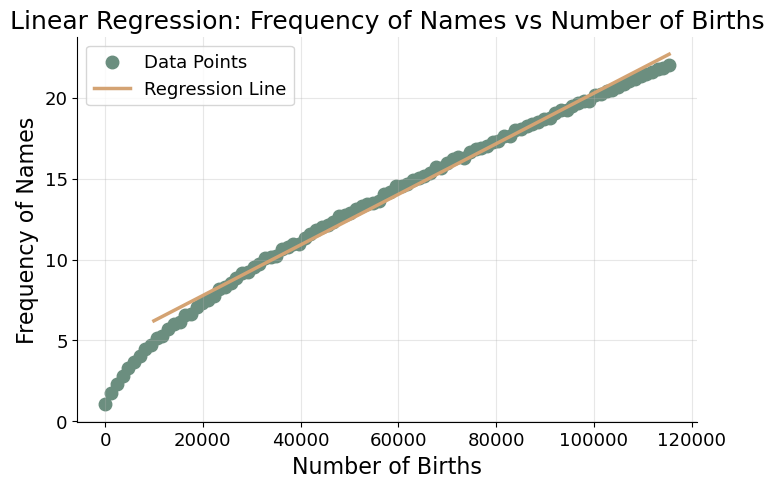

In [ ]:
# Plot: data + regressielijn
fig, ax = plt.subplots(figsize=(8,5))

ax.scatter(df_samples["geboortes"], df_samples["freq_naam"], # teken alle punten uit de df_samples, ook die met geboortes < 10000
           label="Data Points")

x_line = np.linspace(10000, df_samples["geboortes"].max(), 200) # maak 200 x-waarden, te beginnen vanaf 0 tot het maximum aantal geboortes in een rij van df_samples - dit is 1D
y_line = reg.predict(x_line.reshape(-1, 1)) # voorspel de y-waarden met het model dat je met reg = LinearRegression().fit(x_train, y_train) gemaakt hebt - input voor predict moet 2D zijnm dus je maakt de x_line 2D met reshape, de -1 betekent: zoek uit hoeveel rijen er zijn 
ax.plot(x_line, y_line, color=TAN, label="Regression Line")

ax.set_xlabel("Number of Births")
ax.set_ylabel("Frequency of Names")
ax.set_title("Linear Regression: Frequency of Names vs Number of Births")
ax.legend(frameon = True)
ax.grid(True, alpha=0.3)


### Transformatie voor lineaire regressie

In [ ]:
# Log-log transformatie: maakt het sublineaire verband lineair
from sklearn.linear_model import LinearRegression as LR

log_X = np.log(df_samples["geboortes"].values).reshape(-1, 1) # x-input moet 2D zijn dus reshape 
log_y = np.log(df_samples["unieke_namen"].values) # y moet 1D zijn 

reg_log = LR().fit(log_X, log_y)

print(f"Intercept: {reg_log.intercept_}") # intercept is waar de lijn de y-as kruist
print(f"Coefficient: {reg_log.coef_[0]}") # de helling van de lijn, hoeveel stijgt freq_naam als geboorte met 1 toeneemt

# b

Intercept: 3.208978710254545
Coefficient: 0.46605035463849126


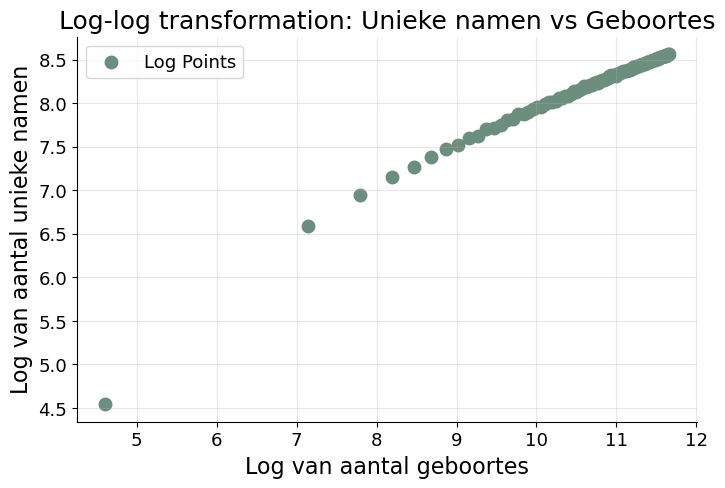

In [ ]:
# Plot: data + regressielijn
fig, ax = plt.subplots(figsize=(8,5))

ax.scatter(log_X, log_y, label="Log Points")

ax.set_xlabel("Log van aantal geboortes")
ax.set_ylabel("Log van aantal unieke namen")
ax.set_title("Log-log transformation: Unieke namen vs Geboortes")
ax.legend(frameon = True)
ax.grid(True, alpha=0.3)

### Validatie plots
#### Valideer de accuraatheid van de frequency names 

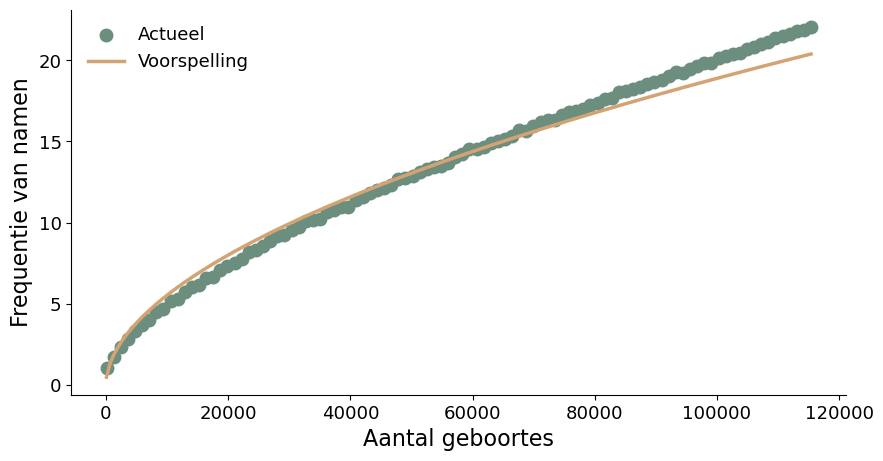

In [73]:
# Validatie: freq_naam — voorspelling via log-log model
x_pred = np.linspace(df_samples["geboortes"].min(), df_samples["geboortes"].max(), 200) # x-input, de punten waarvoor we gaan voorspellen, maak 200 punten van kleinste tot grootste aantal geboortes 
log_pred = reg_log.predict(np.log(x_pred).reshape(-1, 1)) # zet de x-waarden naar log schaal, want we gaan werken met de log-tranformatie; model reg_log, zie hierboven. Maakt 2D met reshape. Het model gaat de log van het aantal namen voorspellen log(unieke_namen)
num_names_pred = np.exp(log_pred) # om van de log terug te gaan naar de originele schaal 
freq_names_pred = x_pred / num_names_pred # de voorspelde gemiddelde frequentie van een naam

fig, ax = plt.subplots()
ax.scatter(df_samples["geboortes"], df_samples["freq_naam"],
           color=SAGE, label="Actueel")
ax.plot(x_pred, freq_names_pred, color=TAN, label="Voorspelling")
ax.set_xlabel("Aantal geboortes")
ax.set_ylabel("Frequentie van namen")
ax.legend()


#### Valideer nu hetzelfde model zijn voorspellingen van totaal aantal verschillende namen

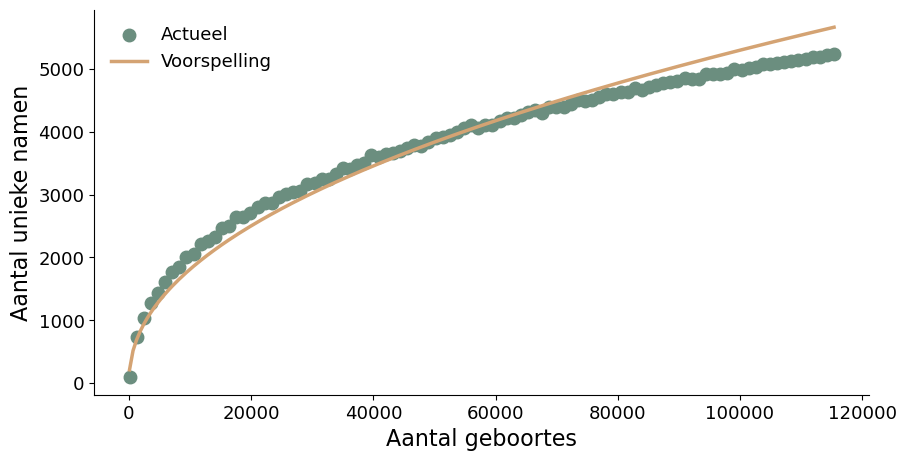

In [66]:

fig, ax = plt.subplots()
ax.scatter(df_samples["geboortes"], df_samples["unieke_namen"],
           color=SAGE, label="Actueel")
ax.plot(x_pred, num_names_pred, color=TAN, label="Voorspelling")
ax.set_xlabel("Aantal geboortes")
ax.set_ylabel("Aantal unieke namen")
ax.legend()


### Verbeterde log-log regressie (alleen samples > 10 000)
De eerste log-log fit gebruikte alle samples, inclusief kleine (< 10 000 geboortes) die veel ruis bevatten. Dit zorgde ervoor dat het model het aantal unieke namen overschatte bij grotere steekproeven. Door alleen te fitten op samples > 10 000 krijgen we een betere fit.

In [68]:
# Log-log regressie, alleen op samples > 10 000
mask_log = df_samples["geboortes"] > 10_000

log_X2 = np.log(df_samples.loc[mask_log, "geboortes"].values).reshape(-1, 1)
log_y2 = np.log(df_samples.loc[mask_log, "unieke_namen"].values)

reg_log2 = LR().fit(log_X2, log_y2)
print(f"Intercept: {reg_log2.intercept_}")
print(f"Coefficient: {reg_log2.coef_[0]}")

Intercept: 4.14893148686546
Coefficient: 0.37967068078907623


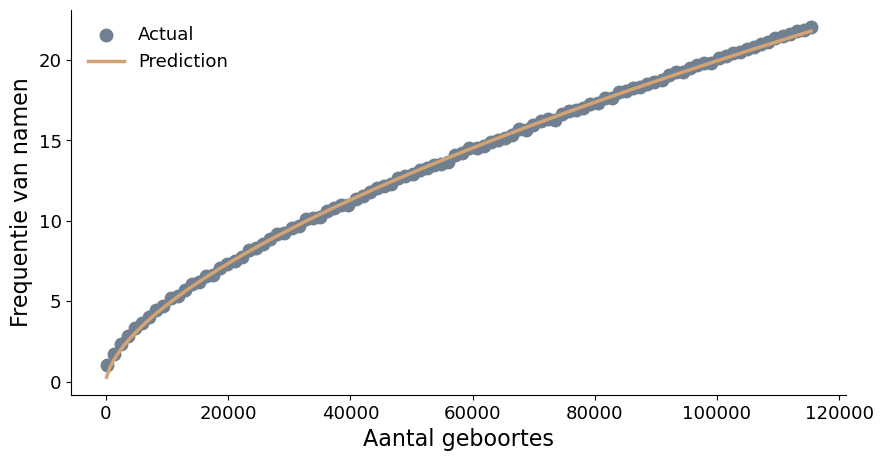

In [71]:
# Validatie freq_names met verbeterd model
x_pred2 = np.linspace(df_samples["geboortes"].min(), df_samples["geboortes"].max(), 200)
log_pred2 = reg_log2.predict(np.log(x_pred2).reshape(-1, 1))
num_names_pred2 = np.exp(log_pred2)
freq_names_pred2 = x_pred2 / num_names_pred2

fig, ax = plt.subplots()
ax.scatter(df_samples["geboortes"], df_samples["freq_naam"],
           color=SLATE, label="Actual")
ax.plot(x_pred2, freq_names_pred2, color=TAN, label="Prediction")
ax.set_xlabel("Aantal geboortes")
ax.set_ylabel("Frequentie van namen")
ax.legend()

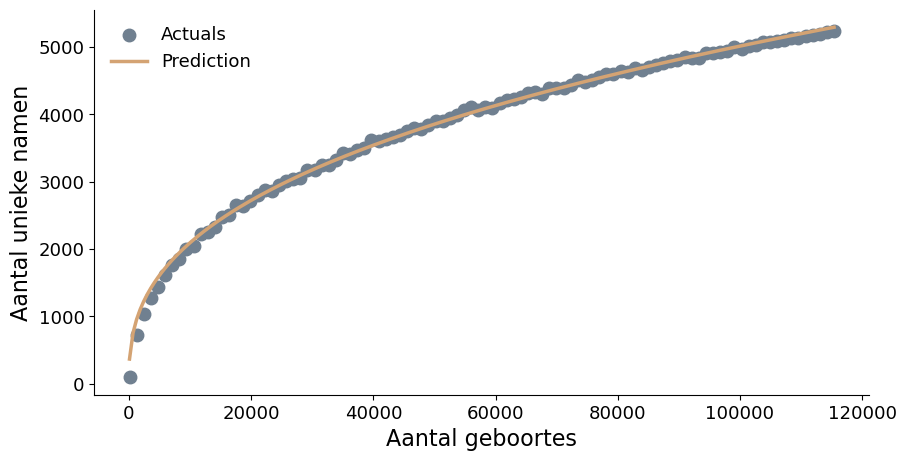

In [72]:
# Validatie num_names met verbeterd model
fig, ax = plt.subplots()
ax.scatter(df_samples["geboortes"], df_samples["unieke_namen"],
           color=SLATE, label="Actuals")
ax.plot(x_pred2, num_names_pred2, color=TAN, label="Prediction")
ax.set_xlabel("Aantal geboortes")
ax.set_ylabel("Aantal unieke namen")
ax.legend()